# COGS 45: Reinforcement Learning Lab

## How do we learn what we should do with only infrequent reward or punishment?

In supervised learning (Weeks 1-2), we had labeled data telling us the right answer for every input. In reinforcement learning, the agent must **discover** what's good and bad through trial and error.

Rewards have some key properties:
* they are <b> sparse </b>
* they are <b> delayed </b>,
* the agent's own <b> actions determine what it experiences next </b>.



In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.dpi'] = 120
np.random.seed(42)


This lab builds up the core ideas of RL step by step:
1. **Intro to explore/exploit dilemma - Multi-Armed Bandits**
2. **Grid-world navigation** — learning state values from experience
3. **Learning algorithms, with increasing efficiency Monte Carlo → TD learning**
4. **Explore vs. exploit again** — balancing knowledge-acquisition and reward-seeking
5. **How environment structure shapes learning** — reward richness × exploration
6. **RLHF** — what happens when *you* are the reward function?

---
## Part 1: The Multi-Armed Bandit — Explore vs. Exploit

### A Concrete Example: <b> Patch Foraging </b>

Imagine you're a bird foraging for berries. You know of three bushes.

* Bush A has given you berries 7 out of 10 visits.
* Bush B you've only tried once and got nothing.
* Bush C you've never tried at all.

**Should you keep going to Bush A (exploit what you know) or try B again or C for the first time (explore)?**

What are the relevant considerations?

If you always exploit, you might miss a bush that's actually much better than A. If you always explore, you waste time on bad bushes you've already tested.

This is the **explore/exploit dilemma** — one of the most fundamental problems in decision-making, studied in ecology (Charnov's marginal value theorem, 1976), psychology (probability matching), neuroscience (dopamine and prediction errors), and AI (reinforcement learning).



The simplest mathematical version of this problem is the **multi-armed bandit**: imagine $k$ slot machines in a casino, each with a different (unknown) average payout. Each pull gives you a **noisy sample** from that machine's reward distribution.

**What does "noisy sample" mean concretely?** Suppose Machine #3 has a true average payout of 2.00 dollars, but on any single pull it might pay 0.50, 3.10, 1.80, or 2.40. The *average* is \$2.00, but each individual pull varies randomly around that average. You never see the true average directly — you only see these noisy individual outcomes, and must figure out which machine is best from experience.

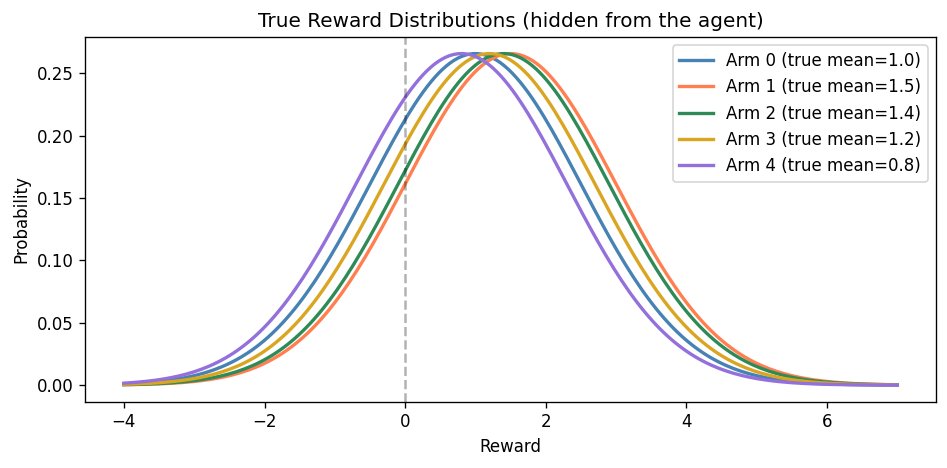

In [2]:
# ============================================================
# MULTI-ARMED BANDIT
# ============================================================
# 5 slot machines with different hidden mean rewards
# The agent doesn't know these — it must learn from experience!

n_arms = 5
true_means = [1.0, 1.5, 1.4, 1.2, 0.8]  # arm 2 (index 2) is secretly the best
noise_std = 1.5  # rewards are noisy!

def pull_arm(arm):
    """Pull an arm and get a noisy reward."""
    return np.random.normal(true_means[arm], noise_std)

# Visualize the true reward distributions (the agent doesn't see this!)
fig, ax = plt.subplots(figsize=(8, 4))
x = np.linspace(-4, 7, 200)
colors = ['steelblue', 'coral', 'seagreen', 'goldenrod', 'mediumpurple']
for i in range(n_arms):
    from scipy.stats import norm
    ax.plot(x, norm.pdf(x, true_means[i], noise_std), color=colors[i],
            label=f'Arm {i} (true mean={true_means[i]})', linewidth=2)
ax.set_xlabel('Reward')
ax.set_ylabel('Probability')
ax.set_title('True Reward Distributions (hidden from the agent)')
ax.legend()
ax.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


###<b> The Epsilon-Greedy Strategy </b>

At each step, the agent flips a (biased) coin:

With probability <b> ε </b> (epsilon), it explores — picks a random arm, ignoring everything it knows. This is how it discovers new information.

With probability <b> 1 - ε </b>, it exploits — picks whichever arm has the highest estimated value so far. This is how it cashes in on what it's already learned.

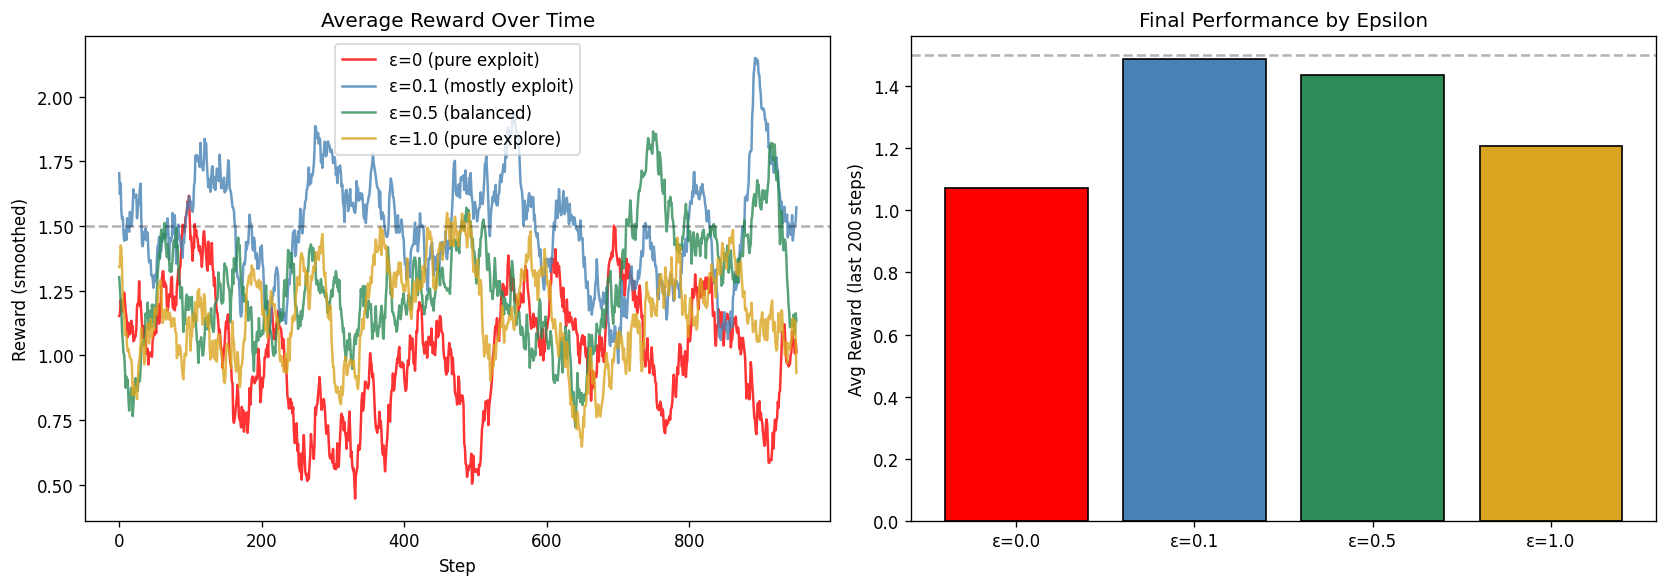

In [9]:
# ============================================================
# EPSILON-GREEDY BANDIT AGENT
# ============================================================

def run_bandit(epsilon, n_steps=1000):
    """Run epsilon-greedy bandit for n_steps.
    epsilon = probability of exploring (choosing randomly)."""

    Q = np.zeros(n_arms)          # estimated value of each arm
    N = np.zeros(n_arms)          # number of times each arm was pulled
    rewards_over_time = []
    choices_over_time = []

    for t in range(n_steps):
        # Explore or exploit?
        if random.random() < epsilon:
            action = random.randint(0, n_arms - 1)  # explore: random arm
        else:
            action = np.argmax(Q)                     # exploit: best known arm

        # Pull the arm and observe reward
        reward = pull_arm(action)

        # Update our estimate (incremental mean)
        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]

        rewards_over_time.append(reward)
        choices_over_time.append(action)

    return Q, N, rewards_over_time, choices_over_time

# Compare different values of epsilon
epsilons = [0.0, 0.1, 0.5, 1.0]
labels = ['ε=0 (pure exploit)', 'ε=0.1 (mostly exploit)',
          'ε=0.5 (balanced)', 'ε=1.0 (pure explore)']
colors_eps = ['red', 'steelblue', 'seagreen', 'goldenrod']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for eps, label, col in zip(epsilons, labels, colors_eps):
    Q, N, rewards, choices = run_bandit(eps, n_steps=1000)

    # Smoothed reward over time
    window = 50
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
    axes[0].plot(smoothed, label=label, color=col, alpha=0.8)

    # Final arm pull distribution
    # (we'll plot this for just one epsilon at a time in the next cell)

axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward (smoothed)')
axes[0].set_title('Average Reward Over Time')
axes[0].legend()
axes[0].axhline(y=max(true_means), color='black', linestyle='--', alpha=0.3, label='Optimal')

# Bar chart: average reward in last 200 steps for each epsilon
avg_final = []
for eps in epsilons:
    _, _, rewards, _ = run_bandit(eps, n_steps=1000)
    avg_final.append(np.mean(rewards[-200:]))

axes[1].bar([f'ε={e}' for e in epsilons], avg_final, color=colors_eps, edgecolor='black')
axes[1].set_ylabel('Avg Reward (last 200 steps)')
axes[1].set_title('Final Performance by Epsilon')
axes[1].axhline(y=max(true_means), color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


### Discussion

- Why does pure exploitation ($\varepsilon$=0) perform poorly?
- Why does pure exploration ($\varepsilon$=1) perform poorly?
- Why does $\varepsilon$=0.1 tend to do well?


-How would we expect the optimal epsilon to change if we modified
  * (a) the number of arms
  * (b) the reward difference between arms (e.g., some are really, really good)
  * (c) the noise

### Connections to Cognitive Science

**Probability matching:** Interestingly, humans don't play optimal $\varepsilon$-greedy. One thing we often do is <b> *probability match* </b> — if arm A pays 70% of the time and arm B pays 30%, humans choose A about 70% of the time rather than 100% (which would be optimal). This looks irrational in the lab, but it naturally implements a form of <b> exploration proportional to uncertainty </b>. In a changing environment where reward rates shift over time, probability matching is surprisingly adaptive.

**Addiction as an explore/exploit failure:** Addictive substances can be modeled as arms with front-loaded rewards that deteriorate over time (tolerance). The agent gets locked into a high-exploitation strategy based on early experience, unable to explore alternatives even as the exploited arm's returns decline. The brain's dopamine system — which computes something very like a TD prediction error (Schultz et al., 1997) — may get hijacked, producing artificially strong "exploit" signals.

**Childhood as exploration (Gopnik, 2020):** Childhood may be a prolonged period of high-$\varepsilon$ exploration. Children explore broadly to build models of the world before shifting toward exploitative, goal-directed behavior.


---
## Part 2: Learning to Navigate a Grid-World

The bandit problem had no *states* — you just picked an arm. Real decision-making involves **sequences of actions** where each action changes your state, and the value of an action depends on where it leads.

A common testbed for RL development has been in "grid-worlds". Here, we move to a 4×4 grid-world. The agent starts in the bottom-left corner (state 12) and must reach a reward in the top-right corner (state 3).

**Key RL concepts:**
- **State**: where the agent is (one of 16 grid positions)
- **Action**: up, down, left, right
- **Policy**: which action to take in each state
- **Value**: how good a state is (expected future reward from that state)
- **Trajectory/rollout**: a sequence of states and actions from start to end

The agent starts knowing *nothing* about the grid. It must learn by stumbling around.


In [10]:
# ============================================================
# GRID-WORLD SETUP
# ============================================================

# Load the transition table: state_transition_table[state, action] = next_state
# Actions: 0=up, 1=down, 2=left, 3=right
state_transition_table = np.array([
    [0,  4,  0,  1],   # state 0
    [1,  5,  0,  2],   # state 1
    [2,  6,  1,  3],   # state 2
    [3,  7,  2,  3],   # state 3
    [0,  8,  4,  5],   # state 4
    [1,  9,  4,  6],   # state 5
    [2, 10,  5,  7],   # state 6
    [3, 11,  6,  7],   # state 7
    [4, 12,  8,  9],   # state 8
    [5, 13,  8, 10],   # state 9
    [6, 14,  9, 11],   # state 10
    [7, 15, 10, 11],   # state 11
    [8, 12, 12, 13],   # state 12 (start)
    [9, 13, 12, 14],   # state 13
    [10,14, 13, 15],   # state 14
    [11,15, 14, 15],   # state 15
])

def show_grid(values, title='', rewards=None):
    """Visualize a 4x4 grid of values with annotations."""
    fig, ax = plt.subplots(figsize=(5, 5))
    grid = values.reshape(4, 4)
    ax.imshow(grid, cmap='RdYlGn', aspect='equal')
    for (j, i), val in np.ndenumerate(grid):
        ax.text(i, j, f'{val:.2f}', ha='center', va='center', fontsize=11,
                fontweight='bold' if abs(val) > 0.01 else 'normal')
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_title(title)
    if rewards is not None:
        for idx in range(16):
            r, c = idx // 4, idx % 4
            if rewards[idx] != 0:
                marker = '★' if rewards[idx] > 0 else '✗'
                ax.text(c, r - 0.35, marker, ha='center', fontsize=14, color='white')
    plt.tight_layout()
    plt.show()

def show_path(state_log, title='Agent Path'):
    """Visualize the agent's path through the grid."""
    fig, ax = plt.subplots(figsize=(5, 5))
    grid = np.zeros(16)
    for idx, s in enumerate(state_log):
        grid[s] = max(grid[s], 0.3 + 0.7 * idx / len(state_log))
    ax.imshow(grid.reshape(4, 4), cmap='Blues', aspect='equal', vmin=0, vmax=1)
    # Draw arrows between consecutive states
    for idx in range(len(state_log) - 1):
        r1, c1 = state_log[idx] // 4, state_log[idx] % 4
        r2, c2 = state_log[idx+1] // 4, state_log[idx+1] % 4
        ax.annotate('', xy=(c2, r2), xytext=(c1, r1),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    ax.text(0, 3, 'START', ha='center', va='center', fontsize=8, color='red')
    ax.text(3, 0, 'GOAL', ha='center', va='center', fontsize=8, color='red')
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


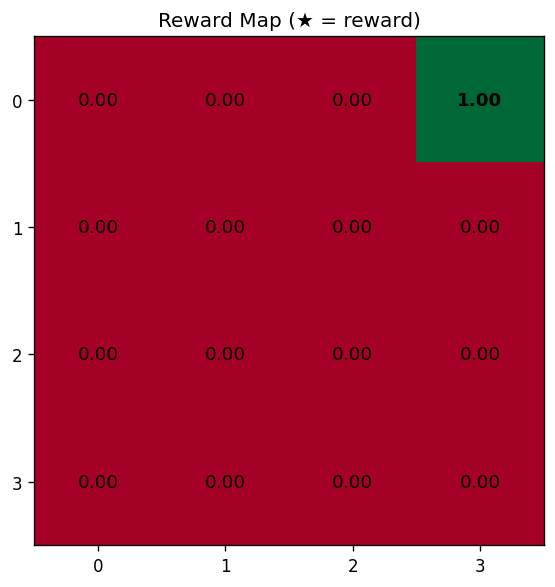

In [11]:
# Set up rewards: one reward in the top-right corner
rewards = np.zeros(16)
rewards[3] = 1  # goal state

# Initialize
state_values = np.zeros(16)
terminal_state = np.argmax(rewards)

# Visualize
show_grid(rewards, 'Reward Map (★ = reward)')


The agent starts in state 12 (bottom-left) and must reach state 3 (top-right, ★).

**Question:** Why can't we just calculate the shortest path?

---
## Part 3: Three Approaches to Learning State Values

Before we dive into code, here's the roadmap. We'll compare three increasingly sophisticated ways to learn how good each state is:

| | **Simple Averaging** | **Monte Carlo** | **TD Learning** |
|---|---|---|---|
| **Core idea** | Average the returns from all rollouts | Update incrementally using a learning rate | Update from the *next prediction*, not the final outcome |
| **When it updates** | After all rollouts | After each complete episode | After each single step |
| **Parameters** | $\gamma$ (discount) | $\gamma$ (discount), $\alpha$ (learning rate) | $\gamma$ (discount), $\alpha$ (learning rate) |
| **Pros** | Simple, unbiased | More efficient, uses learning rate | Most efficient, doesn't need episode to end |
| **Cons** | Very slow, high variance | Must wait for episode to end | Biased (bootstraps from estimates) |
| **Analogy** | Wait until end of semester, average all grades | Update your GPA estimate after each class ends | Update your GPA estimate after each assignment |

The key progression: each method makes **better use of partial information**. Simple averaging wastes information; Monte Carlo uses each episode once; TD uses every single *step*.

### The Update Rules

**Simple averaging:** $V(s) = \text{mean of all observed returns from } s$

**Monte Carlo:** $V(s) \leftarrow V(s) + \alpha \cdot [G_t - V(s)]$ where $G_t$ = total discounted return for the episode

**TD Learning:** $V(s) \leftarrow V(s) + \alpha \cdot [r + \gamma \cdot V(s') - V(s)]$ where $V(s')$ = estimated value of the *next* state

Notice that Monte Carlo uses the *actual* return $G_t$ (unbiased but high variance), while TD uses a *bootstrapped* estimate $r + \gamma V(s')$ (lower variance but biased toward current estimates).


### Approach 1: Average Discounted Returns

The simplest idea: run many random rollouts, and for each state, average the total (discounted) reward the agent received after visiting that state.

**Discount rate (γ):** Future rewards are worth less than immediate rewards. A reward $r$ received $t$ steps in the future is worth $\gamma^t \cdot r$. This is our first parameter.


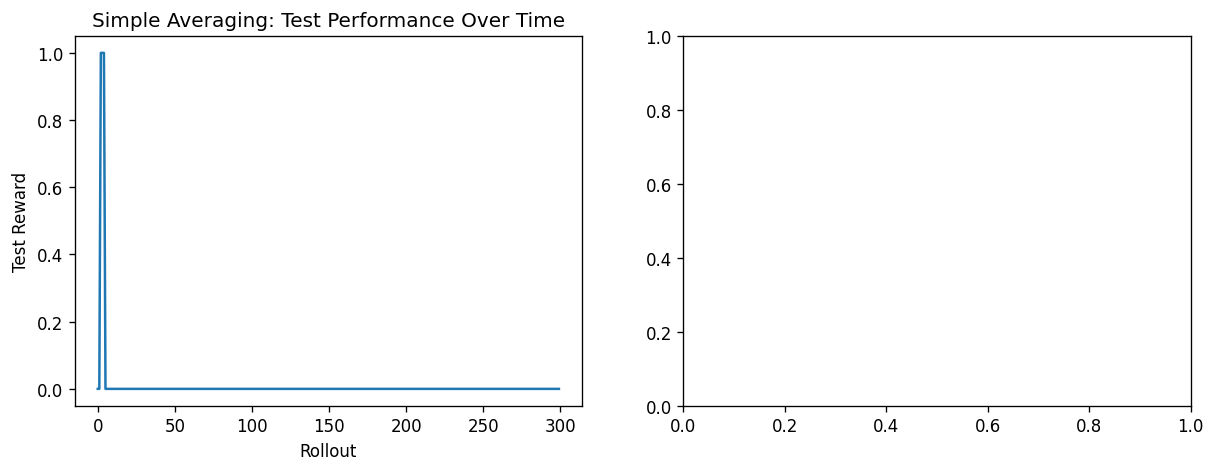

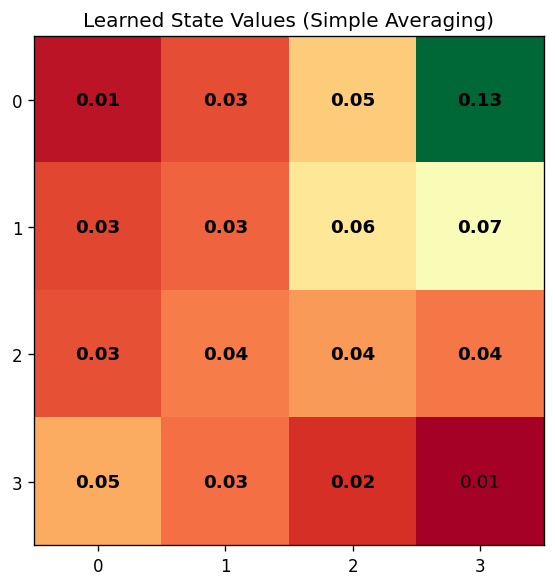

In [12]:
# ============================================================
# APPROACH 1: Average Discounted Returns
# ============================================================

def compute_returns(rewards_list, states_list, gamma=0.9):
    """Compute discounted returns for each state from one rollout."""
    state_returns = np.zeros(16)
    state_count = np.zeros(16)
    R = 0
    for i in reversed(range(len(rewards_list))):
        R = rewards_list[i] + gamma * R
        state_returns[states_list[i]] += R
        state_count[states_list[i]] += 1
    return state_returns / (state_count + 1e-10)

def test_agent(state_values, rewards, terminal_state, max_steps=30):
    """Test: agent follows greedy policy (always picks highest-value next state)."""
    state = 12
    total_reward = 0
    states_log = [state]
    steps = 0
    while state != terminal_state and steps < max_steps:
        action = np.argmax(state_values[state_transition_table[state]])
        state = state_transition_table[state, action]
        total_reward += rewards[state]
        states_log.append(state)
        steps += 1
    return total_reward, states_log

# Train with simple averaging
state_values = np.zeros(16)
returns_log = []
score_log = []

for _ in range(300):
    state = 12
    state_log, reward_log = [], []
    steps = 0
    while state != terminal_state and steps < 15:
        reward_log.append(rewards[state])
        state_log.append(state)
        action = random.randint(0, 3)  # random actions
        state = state_transition_table[state, action]
        steps += 1
    reward_log.append(rewards[state])
    state_log.append(state)

    returns_log.append(compute_returns(reward_log, state_log))
    state_values = np.mean(returns_log, axis=0)
    score_log.append(test_agent(state_values, rewards, terminal_state)[0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(score_log)
axes[0].set_xlabel('Rollout'); axes[0].set_ylabel('Test Reward')
axes[0].set_title('Simple Averaging: Test Performance Over Time')
show_grid(state_values, 'Learned State Values (Simple Averaging)')


### This isn't great! Why?

Averaging over random rollouts is **noisy** — any single rollout is an imperfect estimate because it depends on the random actions taken. The estimate has high **variance** and converges slowly. It also requires storing all past rollouts. So it's costly both in storage and time (amount of experience required).

### Approach 2: Monte Carlo Update

Instead of keeping all rollouts and averaging, we use a **learning rate** (α) to incrementally update our estimates. This is the same idea as the Rescorla-Wagner learning rule:

$$V(s) \leftarrow V(s) + \alpha \cdot (G_t - V(s))$$

where $G_t$ is the return from this rollout and $V(s)$ is our current estimate. We move our estimate a little bit toward the observed return. This introduces our second parameter: **α (learning rate)**.


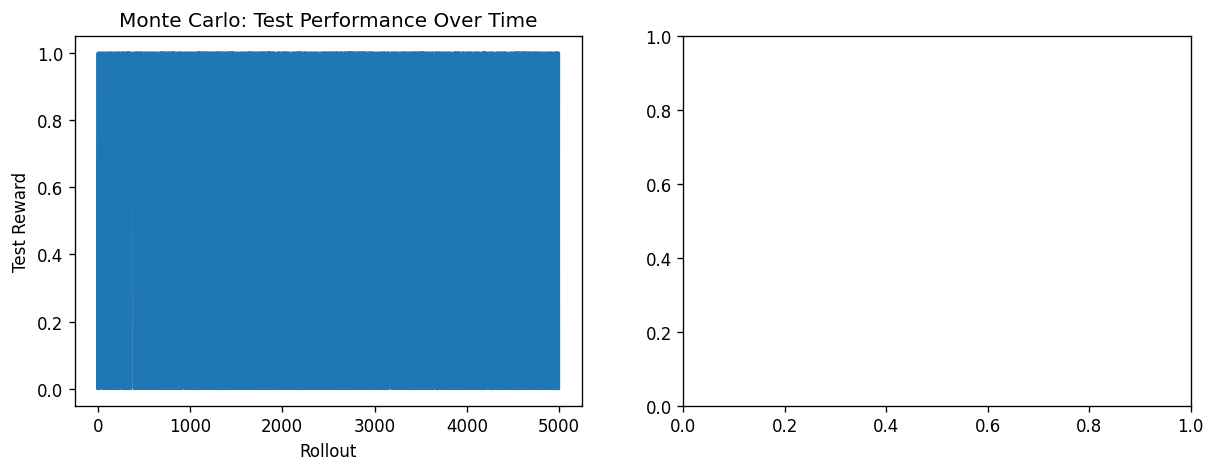

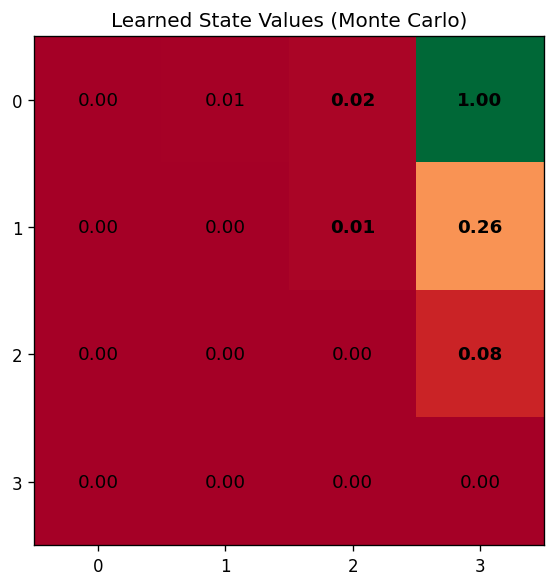

In [13]:
# ============================================================
# APPROACH 2: Monte Carlo Update (with learning rate)
# ============================================================

def monte_carlo_update(values, rewards_list, states_list, gamma=0.9, alpha=0.5):
    """Update value estimates using Monte Carlo returns with a learning rate."""
    returns = []
    R = 0
    for i in reversed(range(len(rewards_list))):
        R = rewards_list[i] + gamma * R
        returns.insert(0, R)

    new_values = values.copy()
    for i, s in enumerate(states_list):
        new_values[s] = values[s] + alpha * (returns[i] - values[s])
    return new_values

# Train with Monte Carlo
state_values = np.zeros(16)
score_log = []

for _ in range(5000):
    state = 12
    state_log, reward_log = [], []
    steps = 0
    while state != terminal_state and steps < 30:
        reward_log.append(rewards[state])
        state_log.append(state)
        action = random.randint(0, 3)
        state = state_transition_table[state, action]
        steps += 1
    reward_log.append(rewards[state])
    state_log.append(state)

    state_values = monte_carlo_update(state_values, reward_log, state_log)
    score_log.append(test_agent(state_values, rewards, terminal_state)[0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(score_log)
axes[0].set_xlabel('Rollout'); axes[0].set_ylabel('Test Reward')
axes[0].set_title('Monte Carlo: Test Performance Over Time')
plt.show()
show_grid(state_values, 'Learned State Values (Monte Carlo)')


---
### Approach 3: Temporal Difference (TD) Learning

Monte Carlo waits until the end of an episode to update. But what if episodes are very long? Or what if the episode is interrupted?

**TD learning** updates after *every step*, using the current estimate of the *next* state's value as a stand-in for the actual return:

$$V(s) \leftarrow V(s) + \alpha \cdot [r + \gamma \cdot V(s') - V(s)]$$

The term $[r + \gamma \cdot V(s') - V(s)]$ is the **TD error** — the difference between what you expected and what you got (plus your estimate of what's coming next). This is "learning a prediction from another prediction."

 Rick Sutton's example: Imagine playing chess and the fire alarm goes off one move before checkmate. With Monte Carlo, you learn nothing (the episode didn't finish). With TD, you still learn — because you update from your *prediction* of the next position's value, not the final outcome.


In [14]:
# ============================================================
# APPROACH 3: TD Learning
# ============================================================

def TD_update(next_val, values, rewards_list, states_list, gamma=0.9, alpha=0.001):
    """Update values using TD learning (bootstrapping from next state's value)."""
    new_values = values.copy()
    nv = next_val
    for i in reversed(range(len(rewards_list))):
        td_error = rewards_list[i] + gamma * nv - values[states_list[i]]
        new_values[states_list[i]] = values[states_list[i]] + alpha * td_error
        nv = values[states_list[i]]
    return new_values


---
### Systematic Comparison: All Three Algorithms on the Same Problem

Let's run all three approaches on the same grid-world and compare their learning curves. This will show the progression in efficiency.


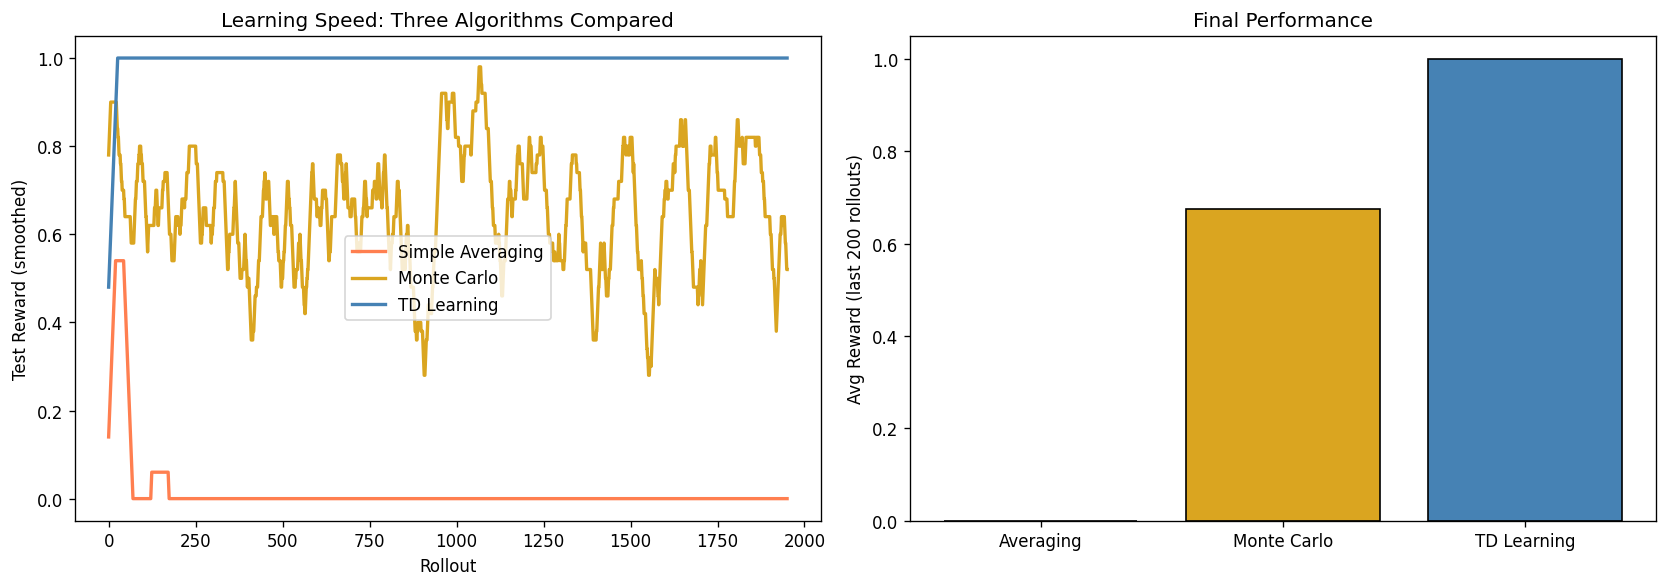

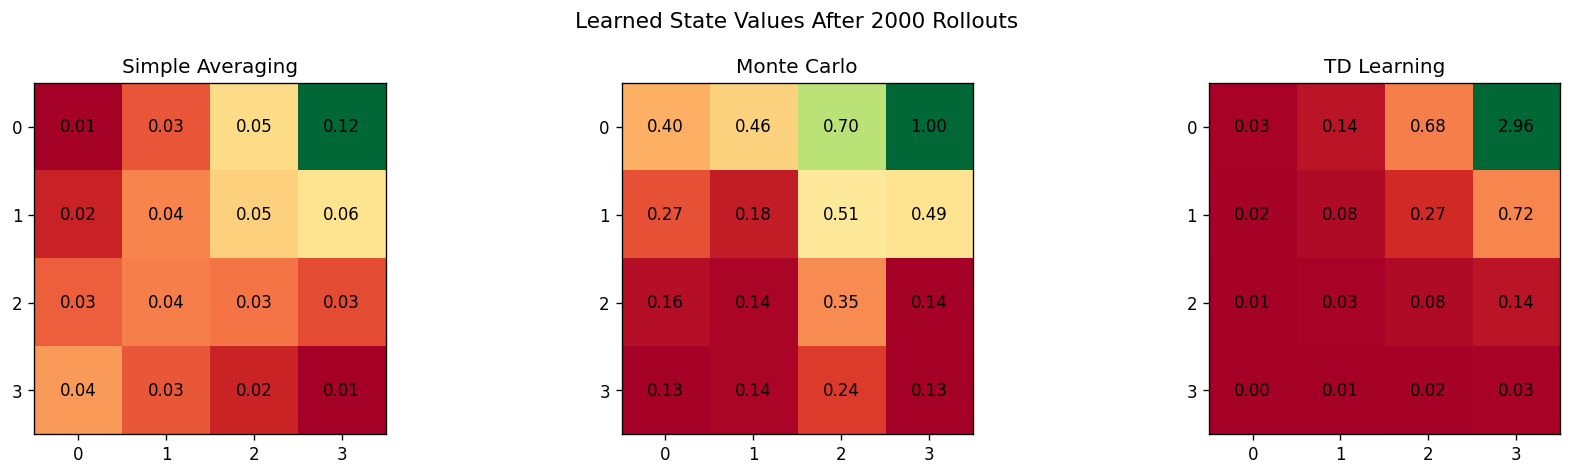

In [15]:
# ============================================================
# SYSTEMATIC COMPARISON OF ALL THREE ALGORITHMS
# ============================================================

def train_averaging(rewards, n_rollouts=500, gamma=0.9, max_steps=15):
    terminal_state = 3
    state_values = np.zeros(16)
    returns_log = []
    score_log = []
    for _ in range(n_rollouts):
        state = 12
        state_log, reward_log = [], []
        steps = 0
        while state != terminal_state and steps < max_steps:
            reward_log.append(rewards[state])
            state_log.append(state)
            action = random.randint(0, 3)
            state = state_transition_table[state, action]
            steps += 1
        reward_log.append(rewards[state])
        state_log.append(state)
        returns_log.append(compute_returns(reward_log, state_log, gamma))
        state_values = np.mean(returns_log, axis=0)
        score_log.append(test_agent(state_values, rewards, terminal_state)[0])
    return state_values, score_log

def train_monte_carlo(rewards, n_rollouts=500, gamma=0.9, alpha=0.5, max_steps=30):
    terminal_state = 3
    state_values = np.zeros(16)
    score_log = []
    for _ in range(n_rollouts):
        state = 12
        state_log, reward_log = [], []
        steps = 0
        while state != terminal_state and steps < max_steps:
            reward_log.append(rewards[state])
            state_log.append(state)
            action = random.randint(0, 3)
            state = state_transition_table[state, action]
            steps += 1
        reward_log.append(rewards[state])
        state_log.append(state)
        state_values = monte_carlo_update(state_values, reward_log, state_log, gamma, alpha)
        score_log.append(test_agent(state_values, rewards, terminal_state)[0])
    return state_values, score_log

# Reset rewards
rewards_simple = np.zeros(16)
rewards_simple[3] = 1

# Run all three (same number of rollouts for fair comparison)
n = 2000
random.seed(42); np.random.seed(42)
sv_avg, sl_avg = train_averaging(rewards_simple, n_rollouts=n)
random.seed(42); np.random.seed(42)
sv_mc, sl_mc = train_monte_carlo(rewards_simple, n_rollouts=n, alpha=0.3)
random.seed(42); np.random.seed(42)
# TD with random exploration (epsilon-greedy comes later in Part 4)
sv_td = np.zeros(16)
sl_td = []
for _ in range(n):
    state = 12; state_log = []; reward_log = []; steps = 0
    while state != 3 and steps < 30:
        reward_log.append(rewards_simple[state]); state_log.append(state)
        action = random.randint(0, 3)
        state = state_transition_table[state, action]; steps += 1
    reward_log.append(rewards_simple[state]); state_log.append(state)
    sv_td = TD_update(sv_td[state], sv_td, reward_log, state_log, gamma=0.9, alpha=0.005)
    sl_td.append(test_agent(sv_td, rewards_simple, 3)[0])

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Learning curves (smoothed)
window = 50
for scores, label, color in [(sl_avg, 'Simple Averaging', 'coral'),
                               (sl_mc, 'Monte Carlo', 'goldenrod'),
                               (sl_td, 'TD Learning', 'steelblue')]:
    smoothed = np.convolve(scores, np.ones(window)/window, mode='valid')
    axes[0].plot(smoothed, label=label, color=color, linewidth=2)
axes[0].set_xlabel('Rollout')
axes[0].set_ylabel('Test Reward (smoothed)')
axes[0].set_title('Learning Speed: Three Algorithms Compared')
axes[0].legend()

# Final values side by side
for ax_idx, (sv, title) in enumerate([(sv_avg, 'Averaging'), (sv_mc, 'Monte Carlo'), (sv_td, 'TD')]):
    # We'll use a single bar chart instead
    pass

# Bar chart: final performance
final_perf = [np.mean(sl_avg[-200:]), np.mean(sl_mc[-200:]), np.mean(sl_td[-200:])]
axes[1].bar(['Averaging', 'Monte Carlo', 'TD Learning'], final_perf,
            color=['coral', 'goldenrod', 'steelblue'], edgecolor='black')
axes[1].set_ylabel('Avg Reward (last 200 rollouts)')
axes[1].set_title('Final Performance')

plt.tight_layout()
plt.show()

# Show final value maps
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, sv, title in [(axes[0], sv_avg, 'Simple Averaging'),
                       (axes[1], sv_mc, 'Monte Carlo'),
                       (axes[2], sv_td, 'TD Learning')]:
    grid = sv.reshape(4, 4)
    ax.imshow(grid, cmap='RdYlGn', aspect='equal')
    for (j, i), val in np.ndenumerate(grid):
        ax.text(i, j, f'{val:.2f}', ha='center', va='center', fontsize=10)
    ax.set_title(title)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
plt.suptitle('Learned State Values After 2000 Rollouts', fontsize=13)
plt.tight_layout()
plt.show()


---
## Part 4: Explore vs. Exploit in the Grid-World

So far, the agent takes **purely random actions** during training. But once it has some knowledge of state values, shouldn't it *use* that knowledge?

The parameter **ε (epsilon)** controls this tradeoff:
- With probability ε, the agent **explores** (random action)
- With probability 1-ε, the agent **exploits** (picks the action leading to the highest-value next state)

This is the same tradeoff we saw in the bandit problem, but now embedded in a sequential decision task.


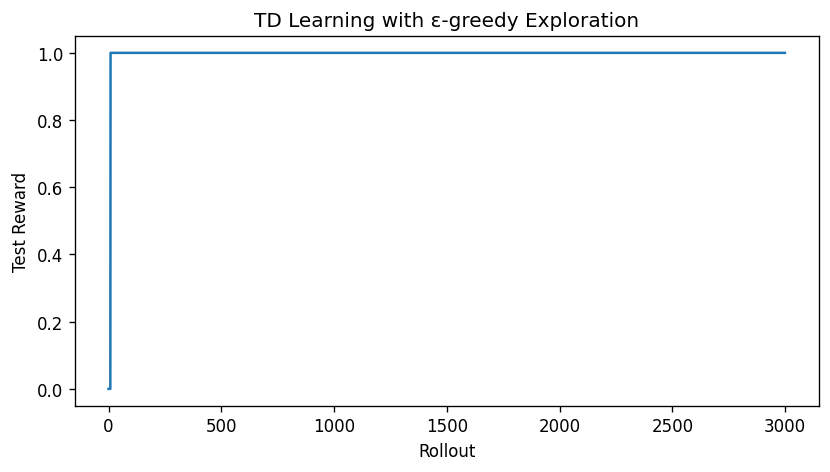

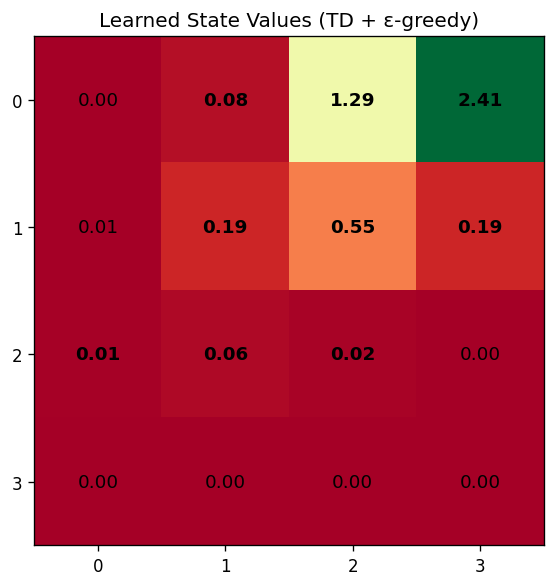

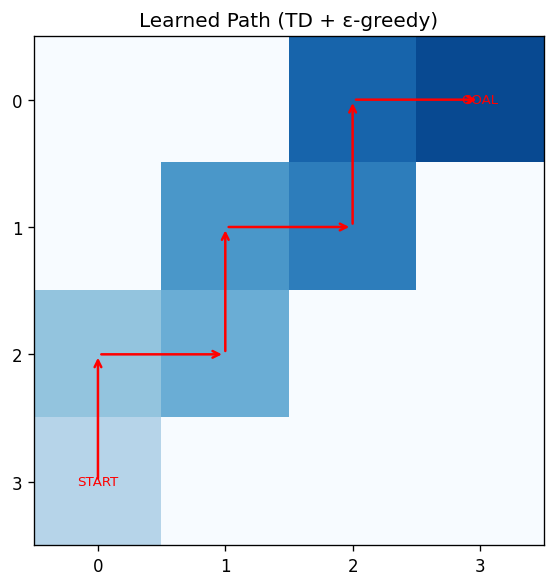

In [16]:
# ============================================================
# TD LEARNING WITH EPSILON-GREEDY EXPLORATION
# ============================================================

def train_td_agent(rewards, epsilon=0.5, n_rollouts=2000, alpha=0.001,
                   gamma=0.9, max_steps=20, decay_epsilon=True):
    """Train a TD-learning agent with epsilon-greedy exploration."""
    terminal_state = np.argmax(np.abs(rewards))  # find terminal state
    state_values = np.zeros(16)
    score_log = []

    for i in range(n_rollouts):
        state = 12  # start bottom-left
        state_log, reward_log = [], []
        steps = 0

        # Optionally decay epsilon over time (explore less as we learn more)
        if decay_epsilon:
            current_eps = max(0.05, epsilon * (1 - i / n_rollouts))
        else:
            current_eps = epsilon

        while state != terminal_state and steps < max_steps:
            state_log.append(state)
            reward_log.append(rewards[state])

            # Explore or exploit?
            if random.random() < current_eps:
                action = random.randint(0, 3)  # explore
            else:
                action = np.argmax(state_values[state_transition_table[state]])  # exploit

            state = state_transition_table[state, action]
            steps += 1

        state_log.append(state)
        reward_log.append(rewards[state])
        next_val = state_values[state]

        state_values = TD_update(next_val, state_values, reward_log, state_log,
                                  gamma=gamma, alpha=alpha)
        score_log.append(test_agent(state_values, rewards, terminal_state)[0])

    return state_values, score_log

# Train with TD + epsilon-greedy
state_values_td, score_log_td = train_td_agent(rewards, epsilon=0.8, n_rollouts=3000)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(score_log_td)
ax.set_xlabel('Rollout'); ax.set_ylabel('Test Reward')
ax.set_title('TD Learning with ε-greedy Exploration')
plt.show()

show_grid(state_values_td, 'Learned State Values (TD + ε-greedy)')

# Show the agent's learned path
_, path = test_agent(state_values_td, rewards, terminal_state)
show_path(path, 'Learned Path (TD + ε-greedy)')


---
## Part 5: Obstacles — What Happens When the Environment Has Dangers?

So far the grid only had a positive reward. What happens when some states are dangerous (negative reward)? The agent must learn to **avoid** bad states while navigating toward the goal.


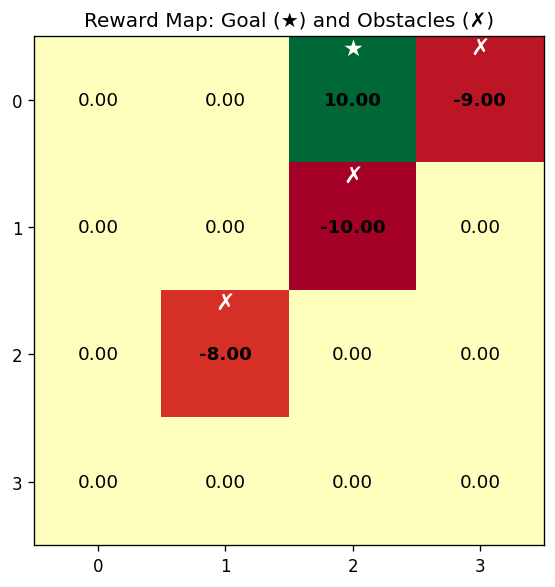

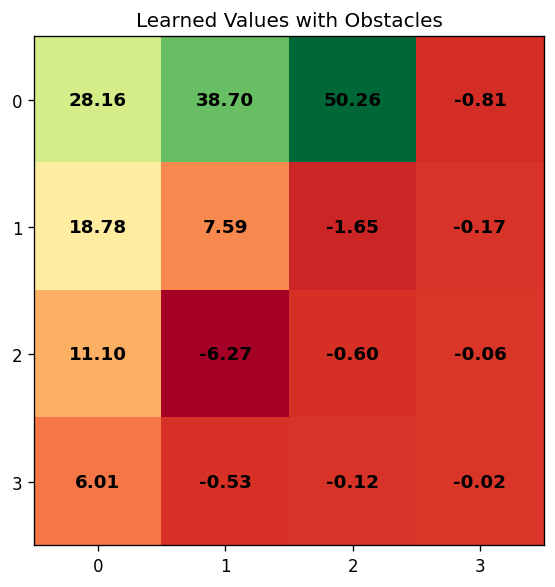

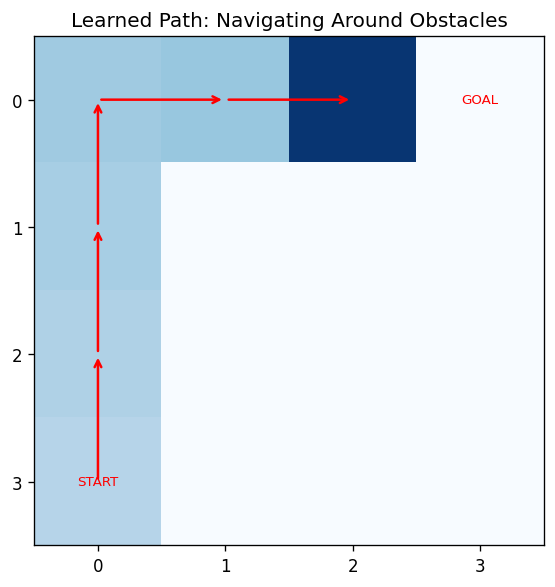

In [28]:
# ============================================================
# GRID WITH OBSTACLES
# ============================================================

rewards_obstacles = np.zeros(16)
rewards_obstacles[2] = 10     # goal (top-right)
rewards_obstacles[6] = -10     # obstacle
rewards_obstacles[9] = -8     # obstacle
rewards_obstacles[3] = -9     # obstacle

show_grid(rewards_obstacles, 'Reward Map: Goal (★) and Obstacles (✗)', rewards_obstacles)

# Train
state_values_obs, score_log_obs = train_td_agent(
    rewards_obstacles, epsilon=0.8, n_rollouts=5000, alpha=0.002)

show_grid(state_values_obs, 'Learned Values with Obstacles')
_, path_obs = test_agent(state_values_obs, rewards_obstacles, 3)
show_path(path_obs, 'Learned Path: Navigating Around Obstacles')


### Your Turn: Design Your Own Environment

Try modifying the rewards above and re-running:
- What happens if you place obstacles that completely block the direct path?
- What if the obstacle penalty is very small (-0.1) vs. very large (-100)?
- What if there are TWO positive reward states with different values — does the agent find the bigger one?

Re-run the training cell after each change and observe how the learned values and path change.


---
## Part 6: How Does the Environment Shape the Explore/Exploit Tradeoff?

*(Adapted from Lina Klinkenberg's COGS 45 final project)*

Not all organisms develop in equally reward-rich environments. Some environments are bountiful — rewards are plentiful, and exploration mostly leads to pleasant surprises. Others are harsh — rewards are scarce and dangers are common, so exploration often leads to punishment.

**Key question:** Does the optimal explore/exploit balance depend on the richness of the environment?

To test this, we set up three environments on our 4×4 grid:
- **Rich**: multiple positive rewards scattered around, no obstacles
- **Mixed**: some positive rewards, some obstacles
- **Harsh**: one small reward, several large obstacles

In each environment, we vary epsilon (how much the agent explores) and measure how much total reward it accumulates during training. Crucially, **rewards are consumed** — once the agent collects a reward at a location, it's gone for the rest of that episode (like eating berries from a bush). This means exploration can discover new reward sources that exploitation would miss.

The episodes run for a **fixed number of steps** — there are no terminal states. The agent just wanders, collecting (or avoiding) whatever it encounters.


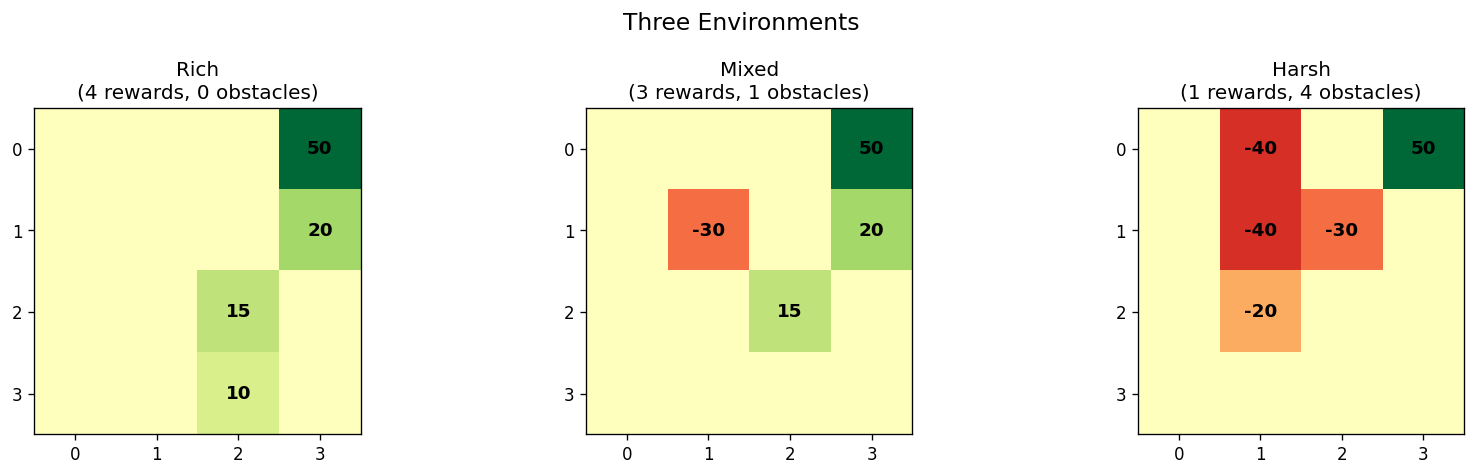

In [29]:
# ============================================================
# REWARD x EPSILON EXPERIMENT
# (adapted from Lina Klinkenberg's COGS 45 project)
# ============================================================
# Key design elements from Lina's original:
#   - Multiple reward/penalty locations (not just one goal)
#   - Rewards are CONSUMED once per episode
#   - Fixed episode length (no terminal states)
#   - Smart exploration: agent avoids revisiting states

# Three environments: Rich, Mixed, Harsh
env_configs = {
    'Rich': {
        3: 50, 7: 20, 10: 15, 14: 10  # 4 rewards, 0 obstacles
    },
    'Mixed': {
        3: 50, 7: 20, 10: 15,          # 3 rewards
        5: -30                           # 1 obstacle
    },
    'Harsh': {
        3: 50,                           # 1 reward
        1: -40, 5: -40, 6: -30, 9: -20  # 4 obstacles
    },
}

# Visualize environments
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, config) in zip(axes, env_configs.items()):
    grid = np.zeros(16)
    for state, val in config.items():
        grid[state] = val
    ax.imshow(grid.reshape(4, 4), cmap='RdYlGn', aspect='equal', vmin=-50, vmax=50)
    for (j, i), val in np.ndenumerate(grid.reshape(4, 4)):
        if val != 0:
            ax.text(i, j, f'{val:.0f}', ha='center', va='center', fontsize=11, fontweight='bold')
    ax.set_title(f'{name}\n({sum(1 for v in config.values() if v>0)} rewards, '
                 f'{sum(1 for v in config.values() if v<0)} obstacles)')
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
plt.suptitle('Three Environments', fontsize=14)
plt.tight_layout()
plt.show()


In [30]:
# ============================================================
# TD update for this experiment (same as before)
# ============================================================

def td_update_exp(values, rewards_list, states_list, gamma=0.9, alpha=0.03):
    new_values = values.copy()
    next_val = values[states_list[-1]]
    for i in reversed(range(len(rewards_list))):
        td_err = rewards_list[i] + gamma * next_val - values[states_list[i]]
        new_values[states_list[i]] = values[states_list[i]] + alpha * td_err
        next_val = values[states_list[i]]
    return new_values

def train_lina_agent(env_config, epsilon, n_rollouts=8000, max_steps=15):
    """Train agent in Lina's paradigm: fixed episode length, consumable rewards."""
    state_values = np.zeros(16)
    cumulative_test_reward = 0
    test_log = []

    for ep in range(n_rollouts):
        state = 12  # start bottom-left
        state_log = []
        reward_log = []
        temp_rewards = np.zeros(16)  # consumable rewards for this episode
        for s, v in env_config.items():
            temp_rewards[s] = v

        for step in range(max_steps):
            state_log.append(state)
            reward_log.append(temp_rewards[state])
            temp_rewards[state] = 0  # consume the reward

            if random.random() < epsilon:
                # SMART explore: prefer unvisited states
                neighbors = state_transition_table[state].tolist()
                unvisited = [s for s in neighbors if s not in state_log]
                if unvisited:
                    state = random.choice(unvisited)
                else:
                    state = state_transition_table[state, random.randint(0, 3)]
            else:
                # Exploit: go to highest-value neighbor
                action = np.argmax(state_values[state_transition_table[state]])
                state = state_transition_table[state, action]

        # Final state
        state_log.append(state)
        reward_log.append(temp_rewards[state])

        # TD update
        state_values = td_update_exp(state_values, reward_log, state_log)

        # Test: greedy rollout with consumable rewards
        test_reward = 0
        test_state = 12
        test_temp = np.zeros(16)
        for s, v in env_config.items():
            test_temp[s] = v
        for _ in range(max_steps):
            test_reward += test_temp[test_state]
            test_temp[test_state] = 0
            action = np.argmax(state_values[state_transition_table[test_state]])
            test_state = state_transition_table[test_state, action]

        cumulative_test_reward += test_reward
        test_log.append(cumulative_test_reward)

    return state_values, test_log, cumulative_test_reward

# ============================================================
# RUN THE EXPERIMENT
# ============================================================

epsilon_values = [0.2, 0.6, 0.99]
epsilon_labels = ['High exploit (0.2)', 'Intermediate (0.6)', 'High explore (0.99)']
n_runs = 3

# Store results
final_scores = np.zeros((len(env_configs), len(epsilon_values), n_runs))
all_curves = {}

for e_idx, (env_name, config) in enumerate(env_configs.items()):
    for eps_idx, eps in enumerate(epsilon_values):
        for run in range(n_runs):
            sv, curve, total = train_lina_agent(config, eps, n_rollouts=8000)
            final_scores[e_idx, eps_idx, run] = total
            all_curves[(env_name, eps, run)] = curve
    print(f"  Finished {env_name}")

print("Done!")


  Finished Rich
  Finished Mixed
  Finished Harsh
Done!


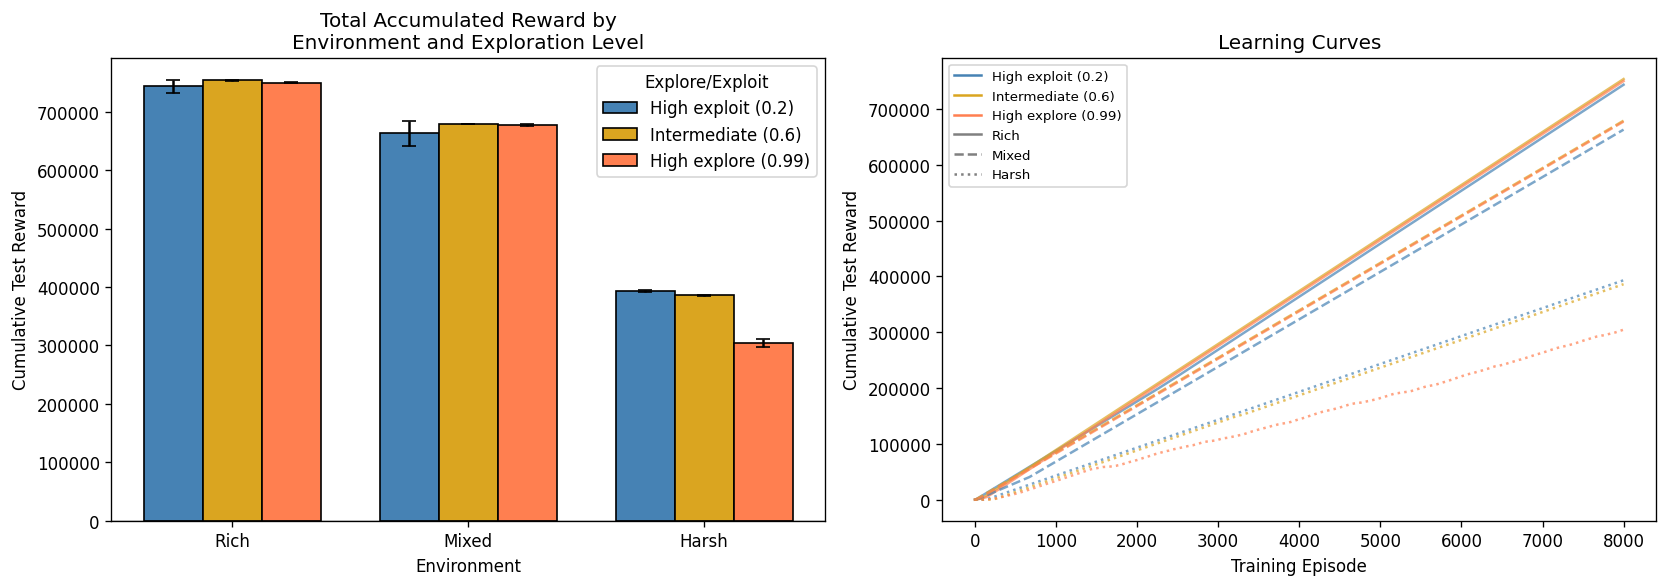

Key question: Does exploration help or hurt, and does it depend on the environment?

In the RICH environment (many rewards, no obstacles):
  -> Exploration discovers multiple reward sources that exploitation might miss

In the HARSH environment (few rewards, many obstacles):
  -> Exploration frequently hits obstacles, accumulating negative reward
  -> Exploitation (once some learning has occurred) avoids the known dangers


In [31]:
# ============================================================
# PLOT THE RESULTS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Bar chart of cumulative test reward
ax = axes[0]
x = np.arange(len(env_configs))
width = 0.25
colors_eps = ['steelblue', 'goldenrod', 'coral']
env_names = list(env_configs.keys())

for eps_idx, (eps, label, col) in enumerate(zip(epsilon_values, epsilon_labels, colors_eps)):
    means = final_scores[:, eps_idx, :].mean(axis=1)
    stds = final_scores[:, eps_idx, :].std(axis=1)
    ax.bar(x + eps_idx * width, means, width, yerr=stds,
           label=label, color=col, edgecolor='black', capsize=4)

ax.set_xlabel('Environment')
ax.set_ylabel('Cumulative Test Reward')
ax.set_title('Total Accumulated Reward by\nEnvironment and Exploration Level')
ax.set_xticks(x + width)
ax.set_xticklabels(env_names)
ax.legend(title='Explore/Exploit')
ax.axhline(y=0, color='black', linestyle='-', alpha=0.2)

# Panel 2: Learning curves for each environment (averaged over runs)
ax = axes[1]
for e_idx, env_name in enumerate(env_names):
    for eps_idx, (eps, col) in enumerate(zip(epsilon_values, colors_eps)):
        curves = [all_curves[(env_name, eps, run)] for run in range(n_runs)]
        mean_curve = np.mean(curves, axis=0)
        style = ['-', '--', ':'][e_idx]
        ax.plot(mean_curve, color=col, linestyle=style, alpha=0.7,
                label=f'{env_name}, eps={eps}' if e_idx == 0 or eps_idx == 0 else '')

ax.set_xlabel('Training Episode')
ax.set_ylabel('Cumulative Test Reward')
ax.set_title('Learning Curves')
# Simplified legend
handles = [plt.Line2D([0], [0], color=c, label=l) for c, l in zip(colors_eps, epsilon_labels)]
handles += [plt.Line2D([0], [0], color='gray', linestyle=s, label=n)
            for s, n in zip(['-', '--', ':'], env_names)]
ax.legend(handles=handles, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

print("Key question: Does exploration help or hurt, and does it depend on the environment?")
print()
print("In the RICH environment (many rewards, no obstacles):")
print("  -> Exploration discovers multiple reward sources that exploitation might miss")
print()
print("In the HARSH environment (few rewards, many obstacles):")
print("  -> Exploration frequently hits obstacles, accumulating negative reward")
print("  -> Exploitation (once some learning has occurred) avoids the known dangers")


### Discussion Questions

1. **What do these results suggest about the relationship between exploration and the reward environment?** Pay attention to the *relative* differences between conditions, not just absolute performance.

2. **Connection to development:** Gopnik (2020) argues that childhood is a period of heavy exploration. These results suggest that exploration is most beneficial in what kind of environment? What happens when exploration is dangerous?

3. **Connection to the real world:** Can you think of a real-world case where a person or system should be strongly biased toward exploration? Toward exploitation? What features of the environment determine which is adaptive?


---
## Part 7: RLHF — You Are the Reward Function

In everything above, we specified the reward function by hand. But in many real-world problems, the right reward is hard to define.

**Reinforcement Learning from Human Feedback (RLHF)** is the technique used to align modern LLMs (including ChatGPT and Claude). The key idea:

1. The system generates several candidate outputs
2. A human **ranks** them
3. The rankings train a **reward model** that predicts human preferences
4. The system is optimized to produce outputs the reward model scores highly

We'll do two RLHF exercises:
- **Exercise A:** You pick a *secret goal location* — the system must figure out where you want the agent to go, purely from your trajectory preferences
- **Exercise B:** You make *aesthetic judgments* between grid patterns — the system learns what visual features you find appealing


EXERCISE A: You chose a SECRET GOAL. Now pick which trajectory
goes closer to where you want the agent to end up.



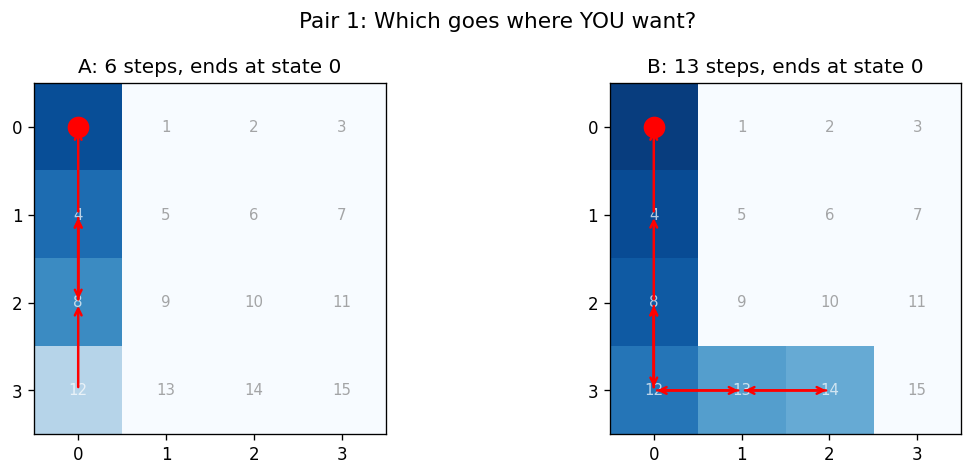

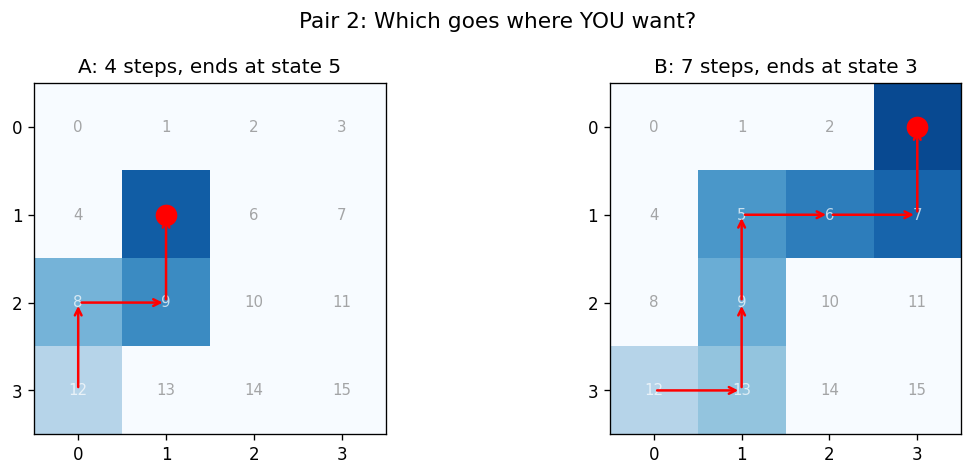

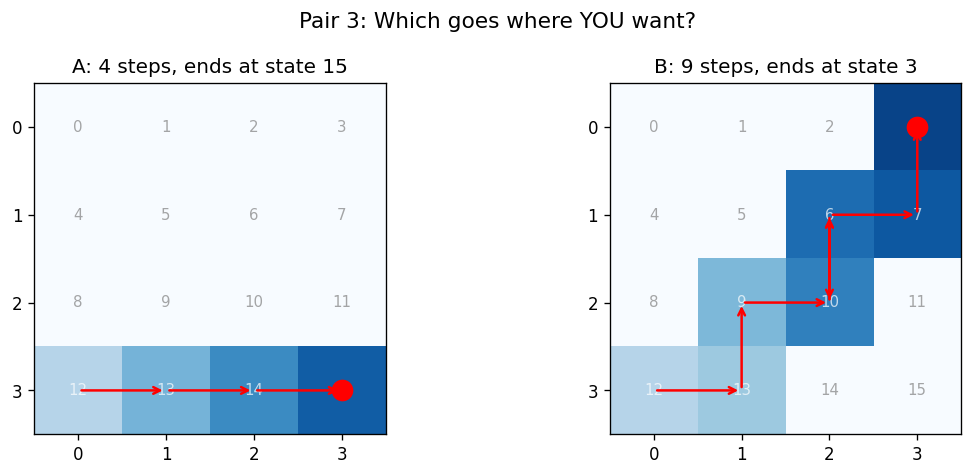

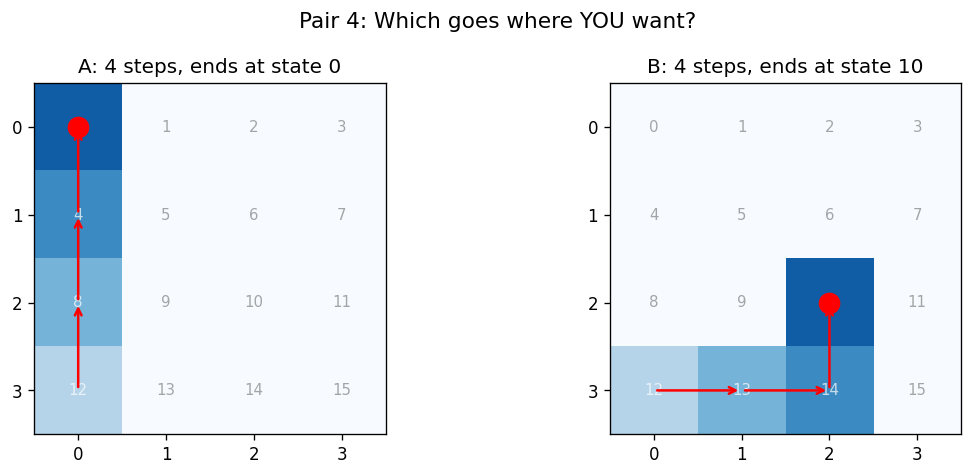

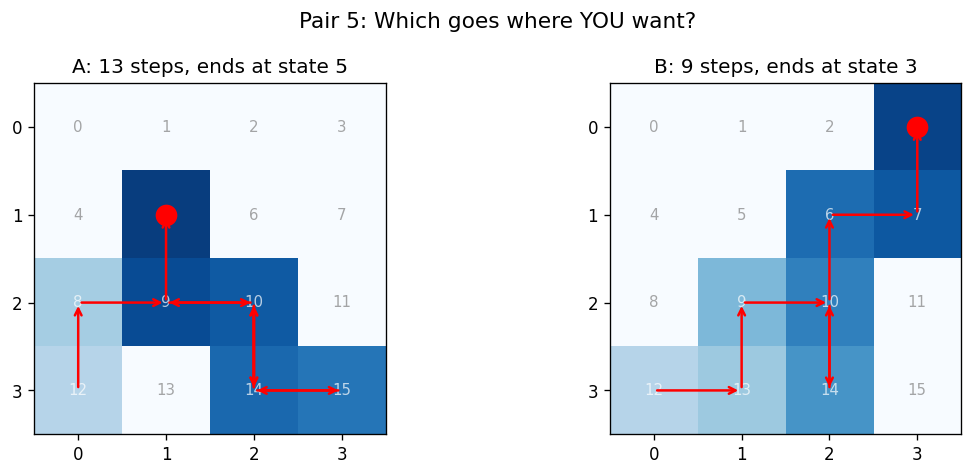

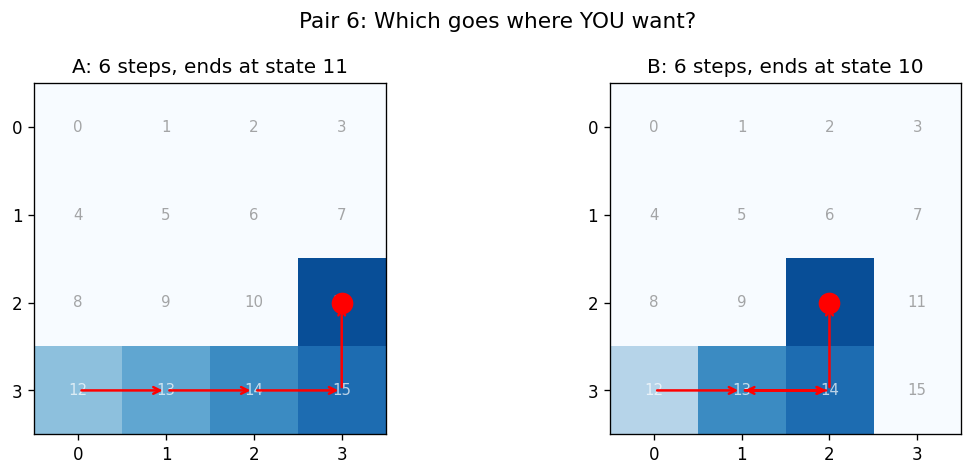

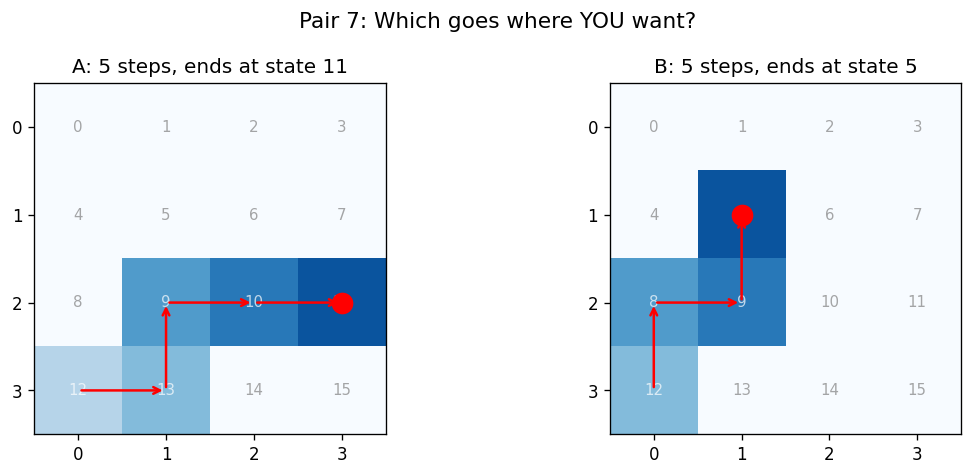

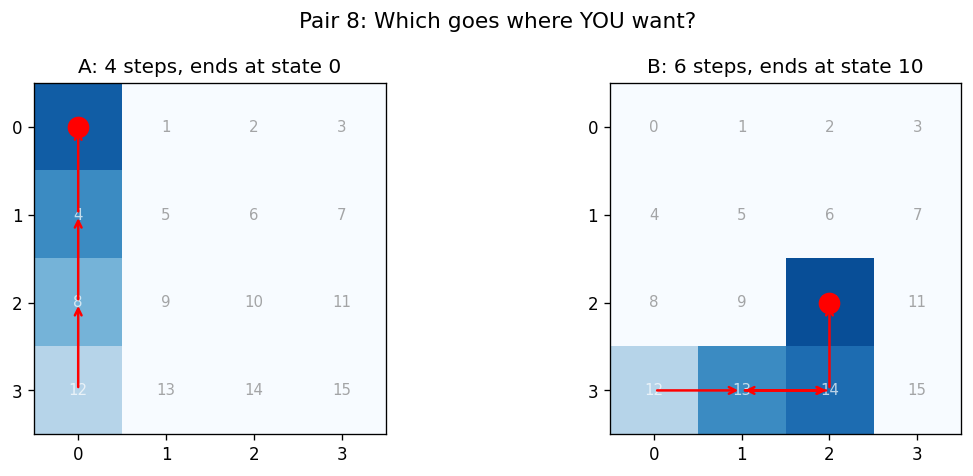

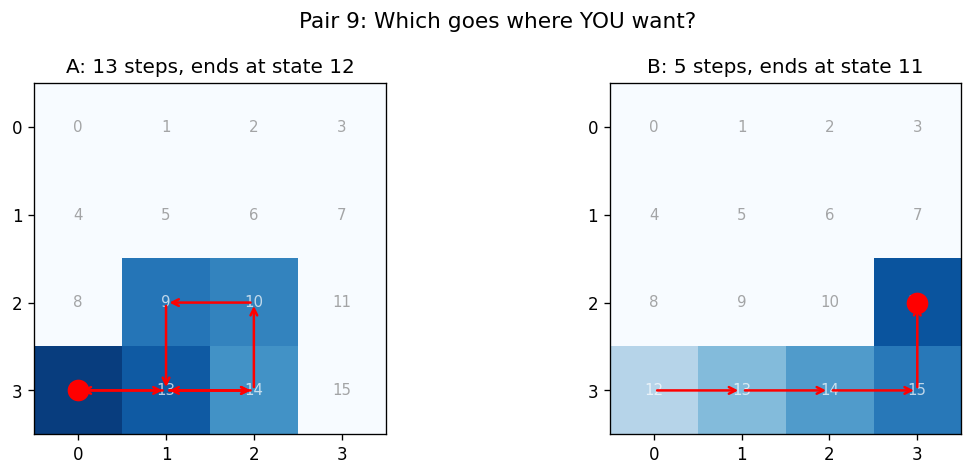

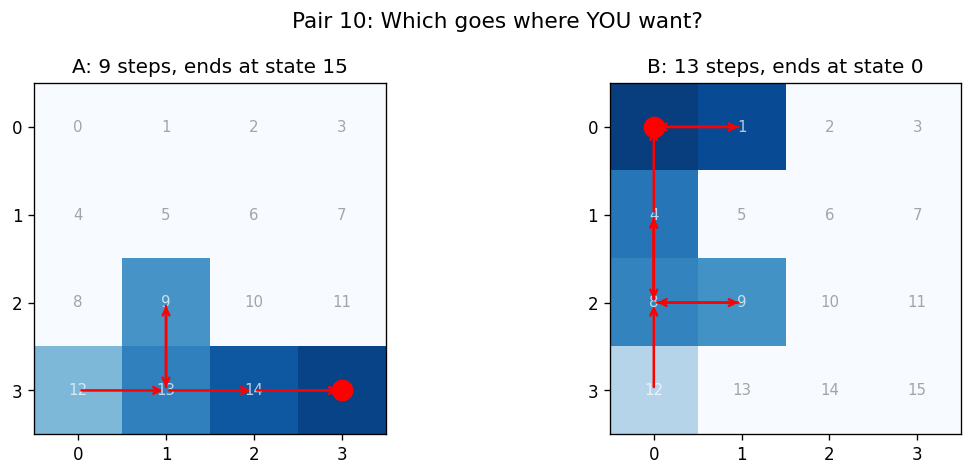

In [33]:
# ============================================================
# RLHF EXERCISE A: SECRET GOAL
# ============================================================
# Pick a secret goal state.
# The system will try to figure out your goal from your preferences.
#
#  0  1  2  3
#  4  5  6  7
#  8  9 10 11
# 12 13 14 15   (12 = start)

MY_SECRET_GOAL = 4  # <-- CHANGE THIS to any state 0-15 (not 12, that's the start)

# Generate trajectories that head toward different locations
def generate_directed_trajectory(target_state, noise=0.3, max_steps=12):
    """Generate trajectory biased toward a target, with some noise."""
    state = 12
    trajectory = [state]
    target_r, target_c = target_state // 4, target_state % 4
    for _ in range(max_steps):
        if random.random() < noise:
            action = random.randint(0, 3)
        else:
            curr_r, curr_c = state // 4, state % 4
            dr, dc = target_r - curr_r, target_c - curr_c
            if abs(dr) > abs(dc):
                action = 0 if dr < 0 else 1  # up or down
            elif dc != 0:
                action = 2 if dc < 0 else 3  # left or right
            else:
                action = random.randint(0, 3)
        state = state_transition_table[state, action]
        trajectory.append(state)
        if state == target_state:
            break
    return trajectory

# Generate trajectories aimed at each of the 4 corners + center + random
targets = [0, 3, 11, 15, 5, 10]  # corners + two interior states
target_names = ['top-left(0)', 'top-right(3)', 'mid-right(11)',
                'bottom-right(15)', 'center-left(5)', 'center-right(10)']

trajectory_pool_a = []
trajectory_targets = []
for t in targets:
    for _ in range(4):
        traj = generate_directed_trajectory(t, noise=0.3)
        trajectory_pool_a.append(traj)
        trajectory_targets.append(t)
# Add some purely random ones
for _ in range(6):
    traj = generate_directed_trajectory(random.randint(0, 15), noise=1.0)
    trajectory_pool_a.append(traj)
    trajectory_targets.append(-1)

# Create 10 pairs — mix trajectories heading to different locations
all_idxs = list(range(len(trajectory_pool_a)))
random.shuffle(all_idxs)
pairs_a = []
for i in range(0, 20, 2):
    a, b = all_idxs[i], all_idxs[i+1]
    if random.random() < 0.5:
        pairs_a.append((a, b))
    else:
        pairs_a.append((b, a))

def show_pair(traj_a, traj_b, pair_num, title_extra=''):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, traj, label in [(axes[0], traj_a, 'A'), (axes[1], traj_b, 'B')]:
        grid = np.zeros(16)
        for idx, s in enumerate(traj):
            grid[s] = max(grid[s], 0.3 + 0.7 * idx / len(traj))
        ax.imshow(grid.reshape(4, 4), cmap='Blues', aspect='equal', vmin=0, vmax=1)
        # Draw state indices on every cell
        for s in range(16):
            r, c = s // 4, s % 4
            ax.text(c, r, str(s), ha='center', va='center', fontsize=9,
                    color='gray' if grid[s] < 0.1 else 'white', alpha=0.7)
        for idx in range(len(traj) - 1):
            r1, c1 = traj[idx] // 4, traj[idx] % 4
            r2, c2 = traj[idx+1] // 4, traj[idx+1] % 4
            ax.annotate('', xy=(c2, r2), xytext=(c1, r1),
                        arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
        end_r, end_c = traj[-1] // 4, traj[-1] % 4
        ax.plot(end_c, end_r, 'o', color='red', markersize=12, zorder=5)
        ax.set_title(f'{label}: {len(traj)} steps, ends at state {traj[-1]}')
        ax.set_xticks(range(4)); ax.set_yticks(range(4))
    fig.suptitle(f'Pair {pair_num}: Which goes where YOU want?', fontsize=13)
    plt.tight_layout()
    plt.show()

print("EXERCISE A: You chose a SECRET GOAL. Now pick which trajectory")
print("goes closer to where you want the agent to end up.\n")

for p_idx, (a, b) in enumerate(pairs_a):
    show_pair(trajectory_pool_a[a], trajectory_pool_a[b], p_idx + 1)


The reward model's best guess for your secret goal: STATE 9
Your actual secret goal: STATE 4
Close?



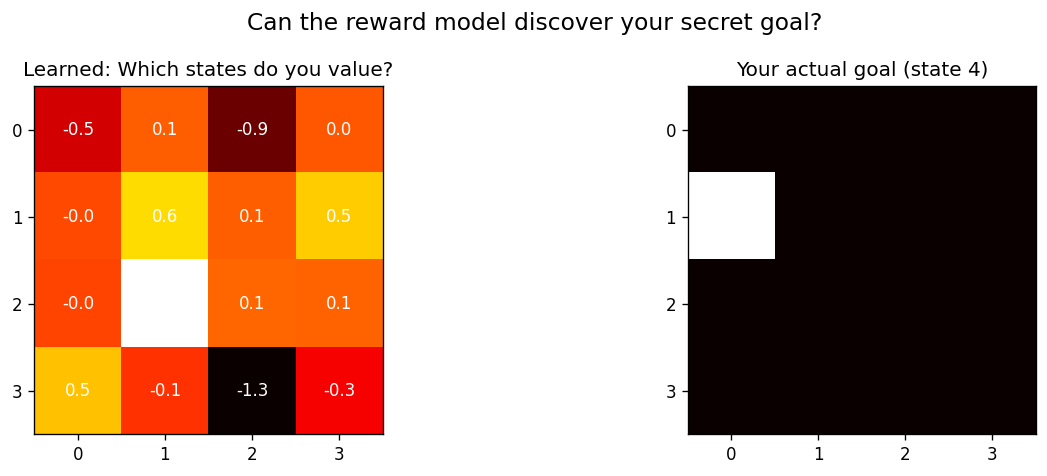

In [34]:
# ============================================================
# Enter preferences for Exercise A, then learn where your goal is
# ============================================================

prefs_a = ['A','A','B','A','A','A','B','B','A','B']  # <-- CHANGE THESE

# Feature: how close does the trajectory end to each possible goal state?
def goal_features_a(traj):
    """For each state, compute: how close did this trajectory end to it?"""
    end_r, end_c = traj[-1] // 4, traj[-1] % 4
    features = np.zeros(16)
    for s in range(16):
        s_r, s_c = s // 4, s % 4
        dist = abs(end_r - s_r) + abs(end_c - s_c)
        features[s] = -dist  # closer = higher feature value
    # Also add: did it actually reach this state?
    for s in set(traj):
        features[s] += 0.5
    return features

from scipy.optimize import minimize

def pref_loss_a(weights, pairs, trajs, prefs):
    loss = 0
    for (a_idx, b_idx), pref in zip(pairs, prefs):
        r_a = np.dot(weights, goal_features_a(trajs[a_idx]))
        r_b = np.dot(weights, goal_features_a(trajs[b_idx]))
        if pref == 'A':
            loss -= np.log(1 / (1 + np.exp(-(r_a - r_b))) + 1e-10)
        else:
            loss -= np.log(1 / (1 + np.exp(-(r_b - r_a))) + 1e-10)
    loss += 0.1 * np.sum(weights ** 2)
    return loss

result_a = minimize(pref_loss_a, np.zeros(16),
                    args=(pairs_a, trajectory_pool_a, prefs_a), method='L-BFGS-B')
goal_weights = result_a.x

# The state with the highest weight is the model's guess for your goal
predicted_goal = np.argmax(goal_weights)

print(f"The reward model's best guess for your secret goal: STATE {predicted_goal}")
print(f"Your actual secret goal: STATE {MY_SECRET_GOAL}")
print(f"{'CORRECT!' if predicted_goal == MY_SECRET_GOAL else 'Close?' }")
print()

# Visualize: learned goal-value map
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: learned weights (which states does the model think you value?)
grid = goal_weights.reshape(4, 4)
ax = axes[0]
ax.imshow(grid, cmap='hot', aspect='equal')
for (j, i), val in np.ndenumerate(grid):
    ax.text(i, j, f'{val:.1f}', ha='center', va='center', fontsize=10, color='white')
ax.set_title('Learned: Which states do you value?')
ax.set_xticks(range(4)); ax.set_yticks(range(4))

# Right: true goal
true_grid = np.zeros((4, 4))
true_grid[MY_SECRET_GOAL // 4, MY_SECRET_GOAL % 4] = 1
ax = axes[1]
ax.imshow(true_grid, cmap='hot', aspect='equal')
ax.text(MY_SECRET_GOAL % 4, MY_SECRET_GOAL // 4, 'GOAL',
        ha='center', va='center', fontsize=12, color='white', fontweight='bold')
ax.set_title(f'Your actual goal (state {MY_SECRET_GOAL})')
ax.set_xticks(range(4)); ax.set_yticks(range(4))

plt.suptitle('Can the reward model discover your secret goal?', fontsize=14)
plt.tight_layout()
plt.show()


Generated 38 patterns across 33 types

EXERCISE B: AESTHETIC PREFERENCE
For each pair, pick which pattern you find more visually APPEALING.
There is no right answer.



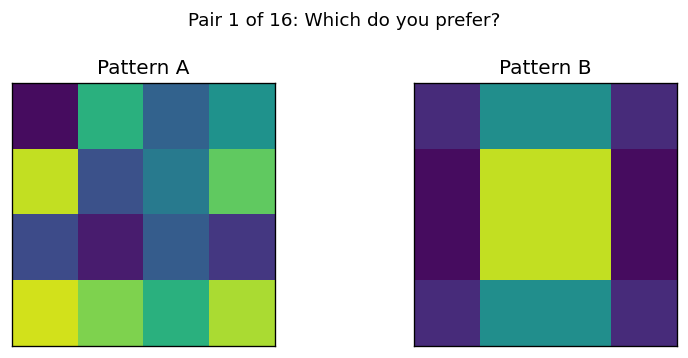

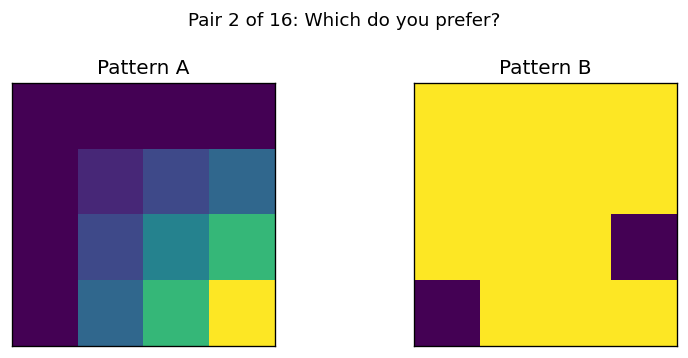

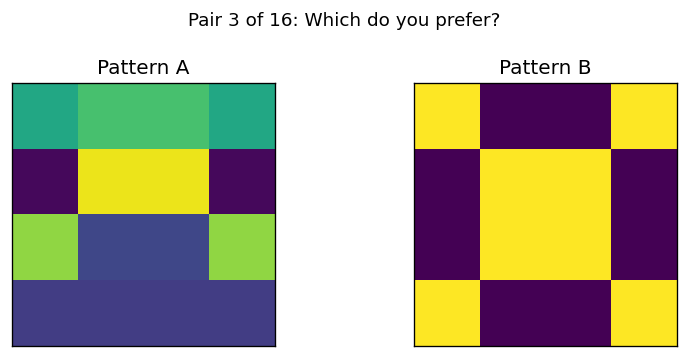

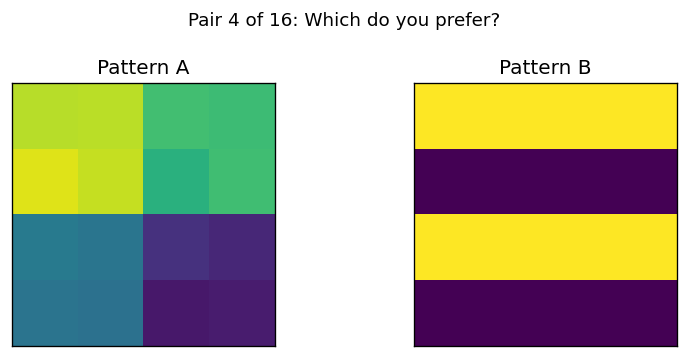

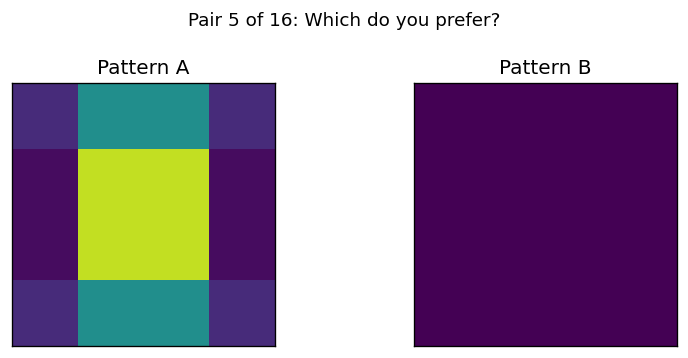

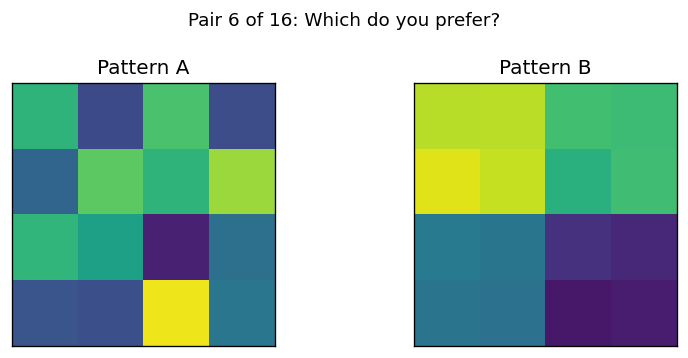

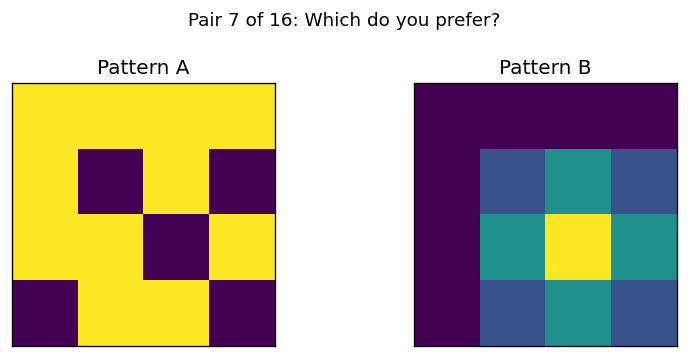

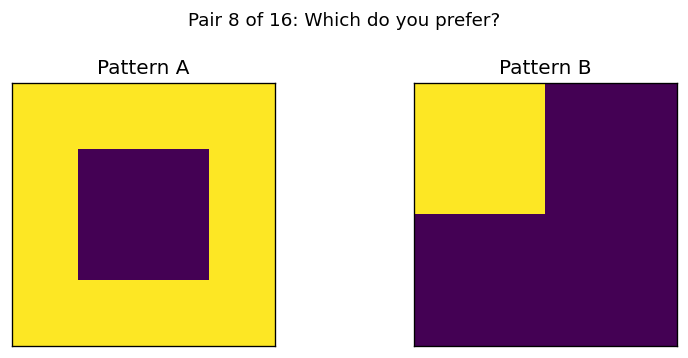

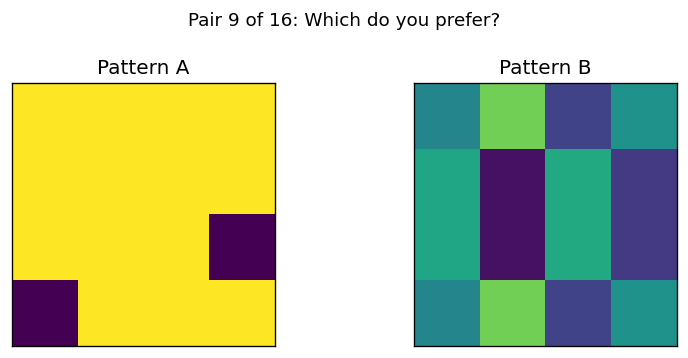

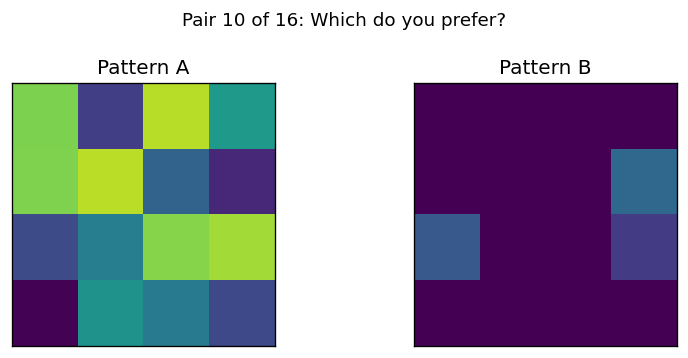

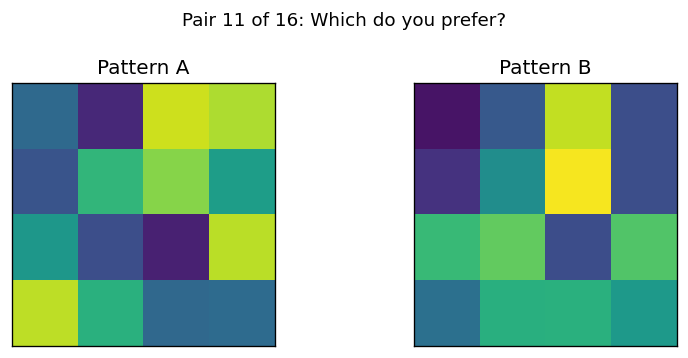

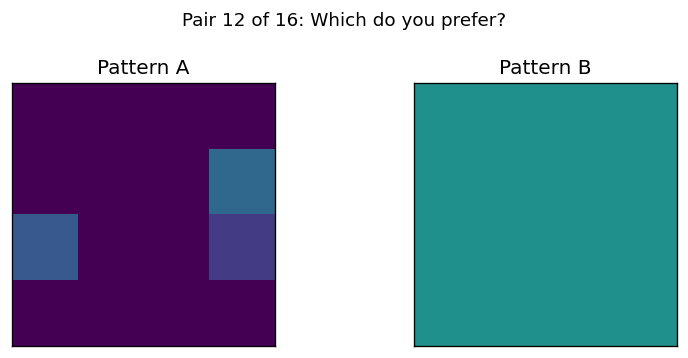

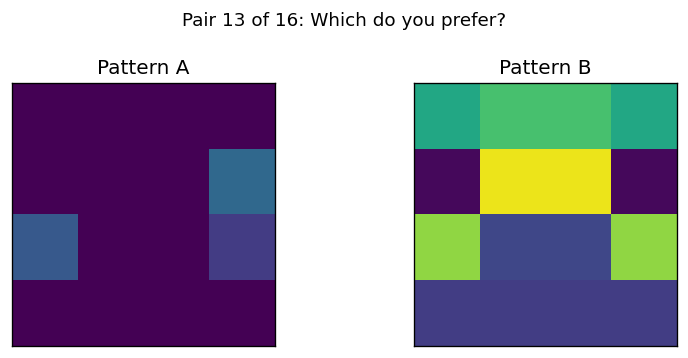

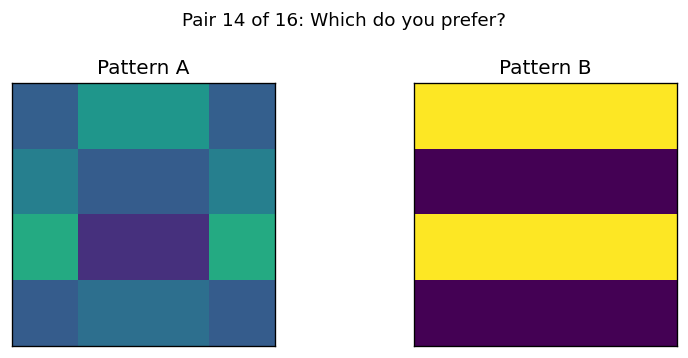

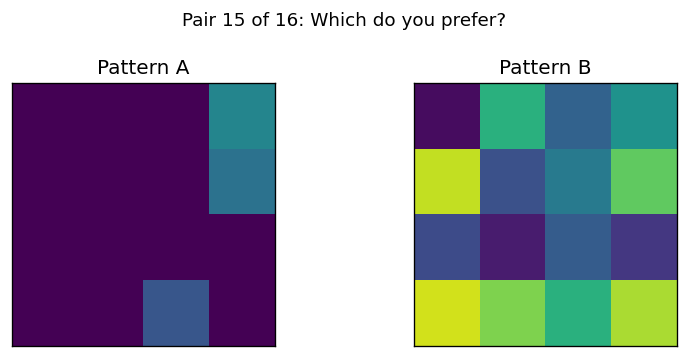

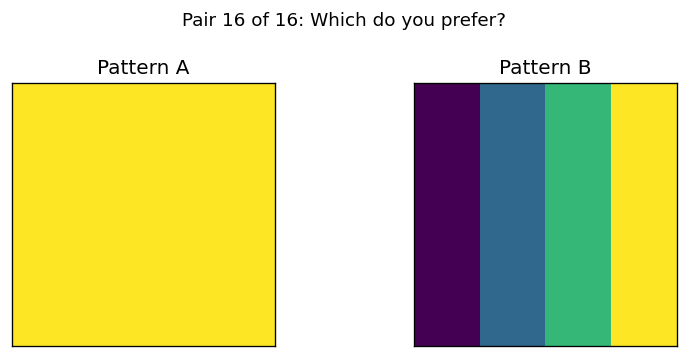

In [35]:
# ============================================================
# RLHF EXERCISE B: AESTHETIC JUDGMENTS
# ============================================================
# Show pairs of 4x4 patterns. Pick which you find more appealing.
# No right answer — purely your taste. The system learns your preferences.

def generate_patterns():
    patterns = []
    labels = []

    # --- SYMMETRIC PATTERNS ---
    # Left-right symmetric (several variants)
    for _ in range(3):
        half = np.random.rand(4, 2)
        patterns.append(np.hstack([half, half[:, ::-1]])); labels.append('symmetric-LR')

    # Top-bottom symmetric
    for _ in range(2):
        half = np.random.rand(2, 4)
        patterns.append(np.vstack([half, half[::-1, :]])); labels.append('symmetric-TB')

    # 4-fold symmetric (LR + TB)
    q = np.random.rand(2, 2)
    full = np.block([[q, q[:, ::-1]], [q[::-1, :], q[::-1, ::-1]]])
    patterns.append(full); labels.append('4-fold-symmetric')

    # --- GRADIENTS ---
    g = np.linspace(0, 1, 4)
    patterns.append(np.outer(g, np.ones(4))); labels.append('gradient-vertical')
    patterns.append(np.outer(np.ones(4), g)); labels.append('gradient-horizontal')
    patterns.append(np.outer(g, g)); labels.append('gradient-diagonal')
    g2 = np.array([0, 0.5, 1.0, 0.5])  # peaked
    patterns.append(np.outer(g2, g2)); labels.append('gradient-peaked')

    # --- REGULAR/GEOMETRIC ---
    c = np.zeros((4, 4))
    c[::2, ::2] = 1; c[1::2, 1::2] = 1
    patterns.append(c); labels.append('checkerboard')

    # Inverse checkerboard
    patterns.append(1 - c); labels.append('checkerboard-inv')

    # Stripes (several orientations)
    s = np.zeros((4, 4)); s[::2, :] = 1
    patterns.append(s); labels.append('stripes-h')
    s2 = np.zeros((4, 4)); s2[:, ::2] = 1
    patterns.append(s2); labels.append('stripes-v')

    # Diamond/X patterns
    d = np.zeros((4, 4))
    d[0,1]=d[0,2]=d[1,0]=d[1,3]=d[2,0]=d[2,3]=d[3,1]=d[3,2]=1
    patterns.append(d); labels.append('diamond')

    x = np.eye(4) + np.eye(4)[:, ::-1]
    x = np.clip(x, 0, 1)
    patterns.append(x); labels.append('X-pattern')

    # Blocks
    b = np.zeros((4, 4)); b[:2, :2] = 1
    patterns.append(b); labels.append('block-corner')
    b2 = np.zeros((4, 4)); b2[1:3, 1:3] = 1
    patterns.append(b2); labels.append('block-center')

    # Border/frame
    fr = np.zeros((4, 4)); fr[0,:]=fr[3,:]=fr[:,0]=fr[:,3]=1
    patterns.append(fr); labels.append('frame')

    # --- HIGH CONTRAST ---
    for _ in range(2):
        hc = np.random.choice([0.0, 1.0], size=(4, 4))
        patterns.append(hc); labels.append('high-contrast-random')

    # --- SMOOTH/BLURRY ---
    for _ in range(2):
        base = np.random.rand(2, 2)
        # Upsample with linear interpolation
        from numpy import repeat
        smooth = repeat(repeat(base, 2, axis=0), 2, axis=1)
        smooth += np.random.rand(4, 4) * 0.1
        smooth = np.clip(smooth, 0, 1)
        patterns.append(smooth); labels.append('smooth-blobs')

    # --- RANDOM NOISE ---
    for k in range(8):
        patterns.append(np.random.rand(4, 4)); labels.append(f'random-{k}')

    # --- SPARSE ---
    for k in range(4):
        sp = np.zeros((4, 4))
        n_dots = random.randint(1, 4)
        for _ in range(n_dots):
            sp[random.randint(0,3), random.randint(0,3)] = random.random()
        patterns.append(sp); labels.append(f'sparse-{k}')

    # --- UNIFORM ---
    patterns.append(np.ones((4, 4)) * 0.5); labels.append('uniform-mid')
    patterns.append(np.zeros((4, 4))); labels.append('uniform-dark')
    patterns.append(np.ones((4, 4))); labels.append('uniform-bright')

    return patterns, labels

patterns, pattern_labels = generate_patterns()
print(f"Generated {len(patterns)} patterns across {len(set(pattern_labels))} types")

# Create 16 pairs with good variety
structured_idxs = [i for i, l in enumerate(pattern_labels)
                   if 'random' not in l and 'sparse' not in l and 'uniform' not in l]
unstructured_idxs = [i for i, l in enumerate(pattern_labels)
                     if 'random' in l or 'sparse' in l or 'uniform' in l]

pairs_b = []
# 8 cross-type pairs (structured vs unstructured)
for _ in range(8):
    a = random.choice(structured_idxs)
    b = random.choice(unstructured_idxs)
    pairs_b.append((a, b) if random.random() < 0.5 else (b, a))

# 4 within-structured pairs (symmetric vs geometric vs gradient)
for _ in range(4):
    a, b = random.sample(structured_idxs, 2)
    pairs_b.append((a, b))

# 4 within-unstructured pairs
for _ in range(4):
    a, b = random.sample(unstructured_idxs, 2)
    pairs_b.append((a, b))

random.shuffle(pairs_b)

print("\nEXERCISE B: AESTHETIC PREFERENCE")
print("For each pair, pick which pattern you find more visually APPEALING.")
print("There is no right answer.\n")

for p_idx, (a, b) in enumerate(pairs_b):
    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    axes[0].imshow(patterns[a], cmap='viridis', aspect='equal', vmin=0, vmax=1)
    axes[0].set_title('Pattern A', fontsize=12)
    axes[0].set_xticks([]); axes[0].set_yticks([])
    axes[1].imshow(patterns[b], cmap='viridis', aspect='equal', vmin=0, vmax=1)
    axes[1].set_title('Pattern B', fontsize=12)
    axes[1].set_xticks([]); axes[1].set_yticks([])
    fig.suptitle(f'Pair {p_idx+1} of {len(pairs_b)}: Which do you prefer?', fontsize=11)
    plt.tight_layout()
    plt.show()


YOUR AESTHETIC PREFERENCE MODEL:



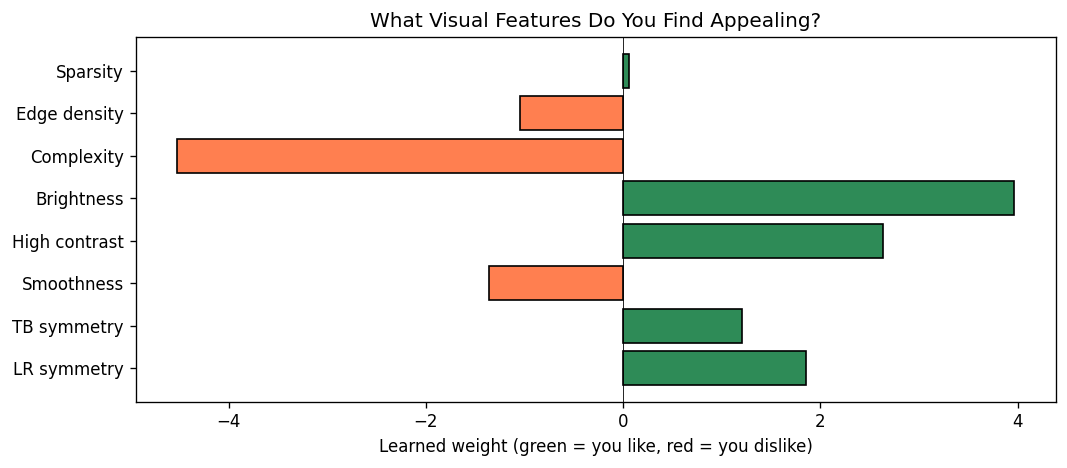

Your strongest preferences:
  DISLIKE Complexity (weight: -4.52)
     LIKE Brightness (weight: +3.96)
     LIKE High contrast (weight: +2.63)
     LIKE LR symmetry (weight: +1.85)
  DISLIKE Smoothness (weight: -1.36)
     LIKE TB symmetry (weight: +1.21)
  DISLIKE Edge density (weight: -1.04)


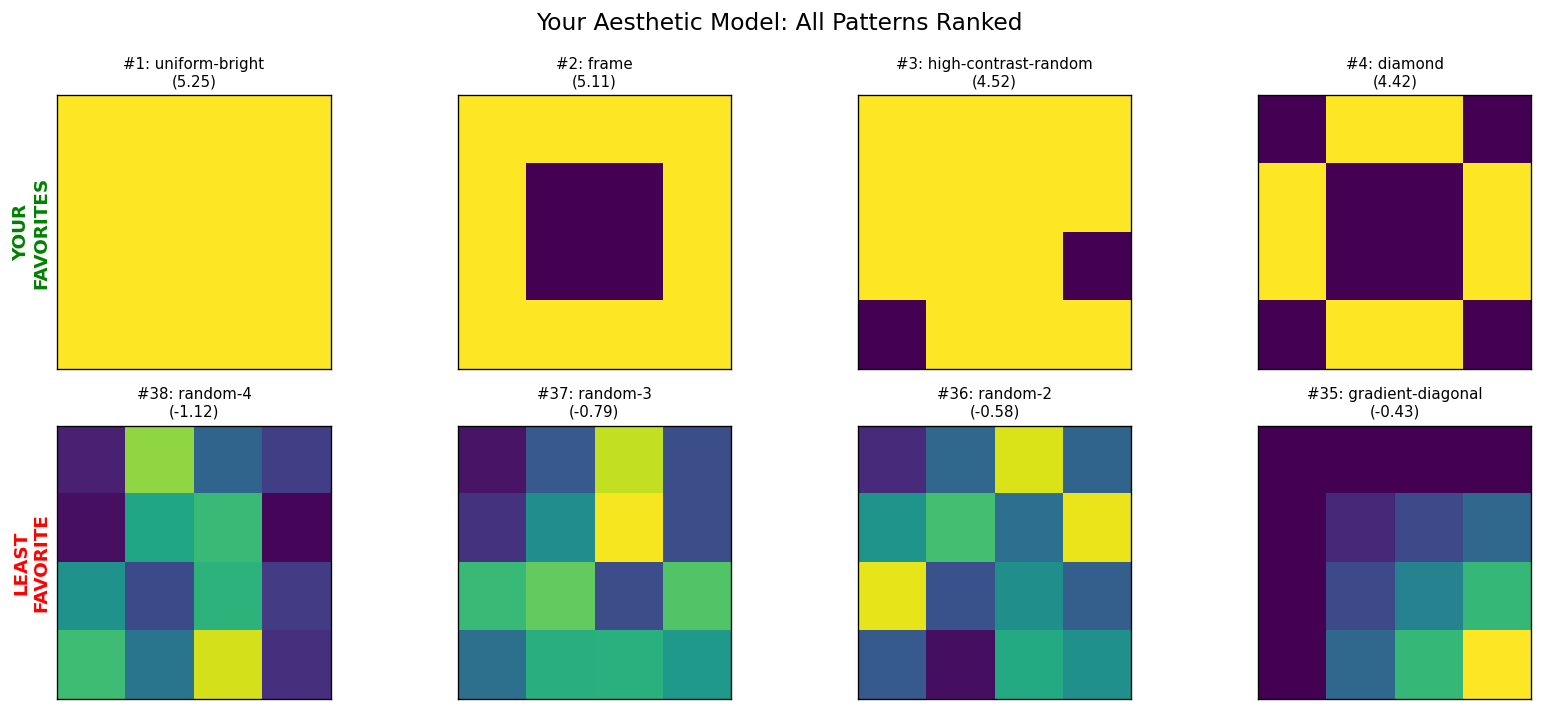


Different people will rank these patterns differently!
That's the point: RLHF learns SUBJECTIVE preferences, not objective truth.
When we train an LLM with RLHF, we're encoding specific humans' values —
which raises the question: whose values, and who decides?


In [38]:
# ============================================================
# Enter your aesthetic preferences (16 pairs)
# ============================================================

prefs_b = ['B','B','B','B','A','B','A','A','A','B','A','B','A','B','B','A']  # <-- CHANGE THESE

assert len(prefs_b) == len(pairs_b), f"Need {len(pairs_b)} preferences, got {len(prefs_b)}"

# Feature extraction: what makes a pattern appealing?
def pattern_features(p):
    p = np.array(p, dtype=float)
    feats = {}

    # Symmetry (left-right): correlation between left and right halves
    feats['LR symmetry'] = 1 - np.mean(np.abs(p - p[:, ::-1]))

    # Symmetry (top-bottom)
    feats['TB symmetry'] = 1 - np.mean(np.abs(p - p[::-1, :]))

    # Smoothness (low differences between neighbors)
    dx = np.mean(np.abs(np.diff(p, axis=1)))
    dy = np.mean(np.abs(np.diff(p, axis=0)))
    feats['Smoothness'] = 1 - (dx + dy) / 2

    # Contrast (standard deviation of values)
    feats['High contrast'] = np.std(p)

    # Density (average brightness)
    feats['Brightness'] = np.mean(p)

    # Complexity (number of unique-ish values)
    feats['Complexity'] = len(np.unique(np.round(p, 1))) / 11.0

    # Edge density (how many sharp transitions)
    edges = (np.abs(np.diff(p, axis=0)) > 0.3).sum() + (np.abs(np.diff(p, axis=1)) > 0.3).sum()
    feats['Edge density'] = edges / 24.0

    # Sparsity (fraction of near-zero cells)
    feats['Sparsity'] = np.mean(p < 0.1)

    return feats

def feat_vec_b(p):
    return np.array(list(pattern_features(p).values()))

feat_names = list(pattern_features(patterns[0]).keys())

from scipy.optimize import minimize

def pref_loss_b(w, pairs, pats, prefs):
    loss = 0
    for (a, b), pref in zip(pairs, prefs):
        ra = np.dot(w, feat_vec_b(pats[a]))
        rb = np.dot(w, feat_vec_b(pats[b]))
        diff = ra - rb if pref == 'A' else rb - ra
        loss -= np.log(1 / (1 + np.exp(-diff)) + 1e-10)
    loss += 0.02 * np.sum(w ** 2)
    return loss

res = minimize(pref_loss_b, np.zeros(len(feat_names)),
               args=(pairs_b, patterns, prefs_b), method='L-BFGS-B')
w_aesthetic = res.x

# Display what the model learned about your taste
print("YOUR AESTHETIC PREFERENCE MODEL:\n")

fig, ax = plt.subplots(figsize=(9, 4))
colors_bar = ['seagreen' if w > 0 else 'coral' for w in w_aesthetic]
ax.barh(feat_names, w_aesthetic, color=colors_bar, edgecolor='black')
ax.set_xlabel('Learned weight (green = you like, red = you dislike)')
ax.set_title('What Visual Features Do You Find Appealing?')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Interpret
print("Your strongest preferences:")
for name, w in sorted(zip(feat_names, w_aesthetic), key=lambda x: -abs(x[1])):
    if abs(w) > 0.2:
        print(f"  {'LIKE' if w > 0 else 'DISLIKE':>7s} {name} (weight: {w:+.2f})")

# Rank ALL patterns
scores_b = [np.dot(w_aesthetic, feat_vec_b(p)) for p in patterns]
rank_b = np.argsort(scores_b)[::-1]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for col in range(4):
    idx = rank_b[col]
    axes[0, col].imshow(patterns[idx], cmap='viridis', aspect='equal', vmin=0, vmax=1)
    axes[0, col].set_title(f'#{col+1}: {pattern_labels[idx]}\n({scores_b[idx]:.2f})', fontsize=9)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])

    idx = rank_b[-(col+1)]
    axes[1, col].imshow(patterns[idx], cmap='viridis', aspect='equal', vmin=0, vmax=1)
    axes[1, col].set_title(f'#{len(patterns)-col}: {pattern_labels[idx]}\n({scores_b[idx]:.2f})', fontsize=9)
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

axes[0, 0].set_ylabel('YOUR\nFAVORITES', fontsize=11, color='green', fontweight='bold')
axes[1, 0].set_ylabel('LEAST\nFAVORITE', fontsize=11, color='red', fontweight='bold')
plt.suptitle('Your Aesthetic Model: All Patterns Ranked', fontsize=14)
plt.tight_layout()
plt.show()

print("\nDifferent people will rank these patterns differently!")
print("That's the point: RLHF learns SUBJECTIVE preferences, not objective truth.")
print("When we train an LLM with RLHF, we're encoding specific humans' values —")
print("which raises the question: whose values, and who decides?")


### Discussion: RLHF and Alignment

1. **Exercise A (Secret Goal):** Did the reward model correctly discover your secret goal? If not, which pairs were most informative vs. least informative? What would it take to reliably identify any goal from preferences alone?

2. **Exercise B (Aesthetics):** Look at the learned feature weights. Do they match your introspective sense of what you find visually appealing? Are there aspects of your preferences that the model's features *can't* capture? (This is the feature engineering problem in ML — the model can only learn over the features you give it.)

3. **Subjectivity and disagreement:** Compare your aesthetic rankings with someone else's. Where do you agree? Where do you disagree? If an AI system were trained on *both* your preferences simultaneously, whose taste would it learn? This is a core challenge in RLHF: aggregating preferences across people who genuinely disagree.



4. **Connection to LLMs:** Modern LLMs are trained in three stages:

* **Pre-training:** The model reads billions of tokens of internet text and learns to predict the next token. No human is labeling anything — the text itself is the training signal. After this stage, the model can generate fluent text, but it doesn't know how to be a helpful assistant. If you prompt it with a question, it might continue it as if it's a webpage, write another question, or produce something totally off-topic. It learned language, not conversation.

* **Supervised fine-tuning (SFT):** Human annotators write out ideal responses to a set of prompts. For example, a human reads "Explain photosynthesis to a 10-year-old" and writes a good, complete answer. The model is then trained on these (prompt, ideal response) pairs using standard supervised learning — the same predict-the-next-token objective, but now the training data is curated human demonstrations of what a good assistant response looks like. This is "imitation" in the behavioral cloning sense: the model learns to copy what expert responses look like. After SFT, the model behaves much more like an assistant, but it's limited to imitating the style and quality of whoever wrote the demonstrations.

* **RLHF:** Now the model generates its own responses, and humans judge them rather than write new ones. The human sees two candidate responses and picks which is better — they never write the "right answer" themselves. A reward model is trained on these judgments, and the model is optimized to produce responses the reward model scores highly. The RLHF step is how the model learns to be "helpful" and "harmless" — concepts that are hard to specify as a loss function but easy for humans to judge in pairwise comparisons.


---
## Value Alignment vs. Representational Alignment

Earlier in this course, we used **Representational Similarity Analysis (RSA)** to compare internal representations across systems. Now we ask: how does representational alignment relate to *value* alignment?

To make this concrete, we train two agents with **different goals** in the **same grid**. They experience the same transitions, so they should learn similar **representations** of how the grid is structured. But they optimize for different outcomes, so their **values** should differ.

To measure representational alignment, we use the **Successor Representation (SR)** — a concept from computational neuroscience (Stachenfeld et al., 2017). For each state, the SR captures: "if I start here, which other states am I likely to visit in the future?" This is a representation of the *environment's dynamics* that is independent of reward.

The key property: **V = SR × r**. Value equals the successor representation times the reward vector. Two agents in the same environment have the same SR but different r, so they have aligned *representations* but misaligned *values*. This separation is exactly the distinction that matters for AI alignment.


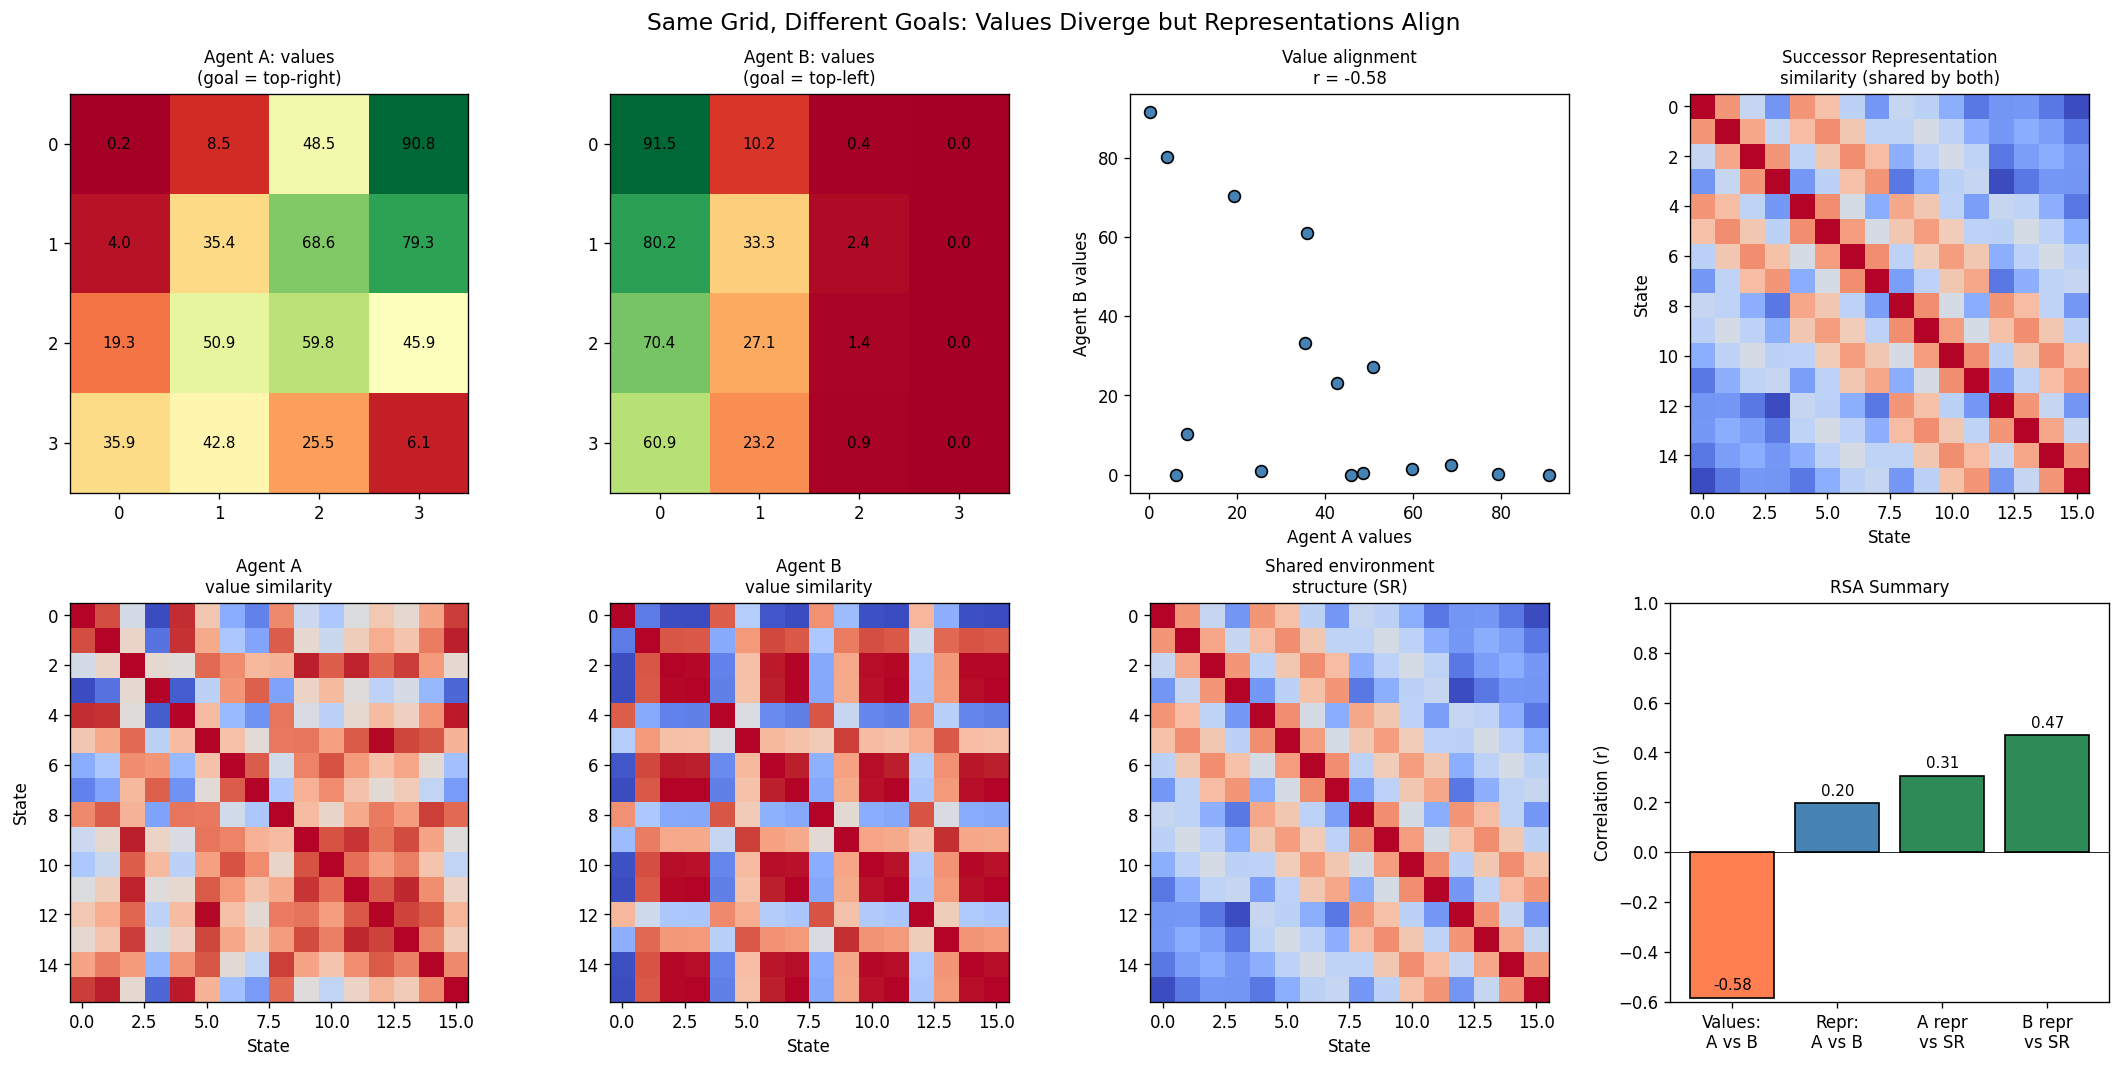

RESULTS:
  Value alignment (do they want the same things?):       r = -0.584
  Repr alignment (do their similarity structures match?): r = 0.196
  Agent A repr vs environment structure (SR):             r = 0.307
  Agent B repr vs environment structure (SR):             r = 0.468

Both agents learned representations that reflect the grid's structure
(high correlation with SR), even though their VALUES are misaligned.

This is the key insight for AI alignment:
  - REPRESENTATIONAL alignment = the system models the world accurately
  - VALUE alignment = the system wants what we want
  - A capable, well-representing system with misaligned values is
    arguably MORE dangerous than an incompetent one.


In [37]:
# ============================================================
# VALUE ALIGNMENT vs REPRESENTATIONAL ALIGNMENT
# ============================================================
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist, squareform

# Train two agents with DIFFERENT goals in the SAME grid
rewards_a = np.zeros(16); rewards_a[3] = 10    # Agent A: goal top-right
rewards_b = np.zeros(16); rewards_b[0] = 10    # Agent B: goal top-left

sv_a, _ = train_td_agent(rewards_a, epsilon=0.7, n_rollouts=5000, alpha=0.005)
sv_b, _ = train_td_agent(rewards_b, epsilon=0.7, n_rollouts=5000, alpha=0.005)

# ============================================================
# Compute the SUCCESSOR REPRESENTATION (SR)
# ============================================================
# The SR captures environment dynamics independent of reward.
# Under a random policy, P(s'|s) = average over actions of T(s,a)=s'
# SR = (I - gamma * P)^{-1}

gamma_sr = 0.9

# Build transition probability matrix under random policy
P = np.zeros((16, 16))
for s in range(16):
    for a in range(4):
        next_s = state_transition_table[s, a]
        P[s, next_s] += 0.25  # uniform over 4 actions

# Successor representation: M = (I - gamma * P)^{-1}
SR = np.linalg.inv(np.eye(16) - gamma_sr * P)

# Verify: V should approximately equal SR @ r
v_check_a = SR @ rewards_a
v_check_b = SR @ rewards_b

# ============================================================
# Compute similarity matrices
# ============================================================
# Representational similarity: based on SR rows (16-dimensional per state)
# Each state's "representation" is its row of the SR matrix
sim_SR = 1 - squareform(pdist(SR, metric='cosine'))  # cosine similarity

# Value similarity for each agent
sim_val_a = 1 - squareform(pdist(sv_a.reshape(-1, 1), metric='euclidean'))
sim_val_b = 1 - squareform(pdist(sv_b.reshape(-1, 1), metric='euclidean'))

# Extract upper triangles for correlation
triu = np.triu_indices(16, k=1)

# RSA: compare similarity structures
rsa_repr_a = pearsonr(sim_SR[triu], sim_val_a[triu])[0]  # SR structure vs A's values
rsa_repr_b = pearsonr(sim_SR[triu], sim_val_b[triu])[0]  # SR structure vs B's values
rsa_val_ab = pearsonr(sv_a, sv_b)[0]                      # A's values vs B's values
rsa_sim_ab = pearsonr(sim_val_a[triu], sim_val_b[triu])[0]  # A's similarity structure vs B's

# ============================================================
# VISUALIZE
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# Row 1: Value maps + value correlation
grid_a = sv_a.reshape(4, 4)
axes[0,0].imshow(grid_a, cmap='RdYlGn', aspect='equal')
for (j,i), v in np.ndenumerate(grid_a):
    axes[0,0].text(i, j, f'{v:.1f}', ha='center', va='center', fontsize=9)
axes[0,0].set_title('Agent A: values\n(goal = top-right)', fontsize=10)
axes[0,0].set_xticks(range(4)); axes[0,0].set_yticks(range(4))

grid_b = sv_b.reshape(4, 4)
axes[0,1].imshow(grid_b, cmap='RdYlGn', aspect='equal')
for (j,i), v in np.ndenumerate(grid_b):
    axes[0,1].text(i, j, f'{v:.1f}', ha='center', va='center', fontsize=9)
axes[0,1].set_title('Agent B: values\n(goal = top-left)', fontsize=10)
axes[0,1].set_xticks(range(4)); axes[0,1].set_yticks(range(4))

axes[0,2].scatter(sv_a, sv_b, c='steelblue', edgecolors='black', s=50)
axes[0,2].set_xlabel('Agent A values'); axes[0,2].set_ylabel('Agent B values')
axes[0,2].set_title(f'Value alignment\nr = {rsa_val_ab:.2f}', fontsize=10)

# SR visualization
sr_grid = SR.reshape(4, 4, 4, 4)  # just show one example row
axes[0,3].imshow(sim_SR, cmap='coolwarm', aspect='equal')
axes[0,3].set_title('Successor Representation\nsimilarity (shared by both)', fontsize=10)
axes[0,3].set_xlabel('State'); axes[0,3].set_ylabel('State')

# Row 2: Similarity matrices + RSA bar chart
axes[1,0].imshow(sim_val_a, cmap='coolwarm', aspect='equal')
axes[1,0].set_title('Agent A\nvalue similarity', fontsize=10)
axes[1,0].set_xlabel('State'); axes[1,0].set_ylabel('State')

axes[1,1].imshow(sim_val_b, cmap='coolwarm', aspect='equal')
axes[1,1].set_title('Agent B\nvalue similarity', fontsize=10)
axes[1,1].set_xlabel('State')

axes[1,2].imshow(sim_SR, cmap='coolwarm', aspect='equal')
axes[1,2].set_title('Shared environment\nstructure (SR)', fontsize=10)
axes[1,2].set_xlabel('State')

# RSA comparison bar chart
ax = axes[1,3]
comparisons = [
    'Values:\nA vs B',
    'Repr:\nA vs B',
    'A repr\nvs SR',
    'B repr\nvs SR'
]
rsa_vals = [rsa_val_ab, rsa_sim_ab, rsa_repr_a, rsa_repr_b]
colors = ['coral', 'steelblue', 'seagreen', 'seagreen']
bars = ax.bar(comparisons, rsa_vals, color=colors, edgecolor='black')
ax.set_ylabel('Correlation (r)')
ax.set_title('RSA Summary', fontsize=10)
ax.set_ylim(-0.6, 1.0)
ax.axhline(y=0, color='black', linewidth=0.5)
# Add value labels
for bar, val in zip(bars, rsa_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.2f}', ha='center', fontsize=9)

plt.suptitle('Same Grid, Different Goals: Values Diverge but Representations Align', fontsize=14)
plt.tight_layout()
plt.show()

print("RESULTS:")
print(f"  Value alignment (do they want the same things?):       r = {rsa_val_ab:.3f}")
print(f"  Repr alignment (do their similarity structures match?): r = {rsa_sim_ab:.3f}")
print(f"  Agent A repr vs environment structure (SR):             r = {rsa_repr_a:.3f}")
print(f"  Agent B repr vs environment structure (SR):             r = {rsa_repr_b:.3f}")
print()
print("Both agents learned representations that reflect the grid's structure")
print("(high correlation with SR), even though their VALUES are misaligned.")
print()
print("This is the key insight for AI alignment:")
print("  - REPRESENTATIONAL alignment = the system models the world accurately")
print("  - VALUE alignment = the system wants what we want")
print("  - A capable, well-representing system with misaligned values is")
print("    arguably MORE dangerous than an incompetent one.")


---
## Summary & Connections

| Concept | Bandit | Grid-World | LLMs |
|---|---|---|---|
| **Explore/Exploit** | Pull random arm vs. best-known arm | Random action vs. highest-value action | Generate diverse responses vs. stick with safe ones |
| **Reward signal** | Slot machine payout | Grid reward | Human preference ranking (RLHF) |
| **Value learning** | Estimated arm means | State values via TD | Reward model from preferences |
| **Key tradeoff** | Short-term reward vs. long-term knowledge | Immediate safety vs. finding the goal | Helpfulness vs. harmlessness |

### Key Takeaways
1. **RL is about learning what to do from sparse, delayed feedback** — very different from supervised learning
2. **TD learning** bootstraps from predictions of predictions — it doesn't need to wait for the end of an episode
3. **The explore/exploit tradeoff** is ubiquitous — in bandits, grid-worlds, child development, and LLM training
4. **The environment shapes the optimal strategy** — harsh environments punish exploration; benign environments reward it
5. **When the reward function is hard to specify, you can learn it from human preferences** — this is RLHF, the technique behind modern LLM alignment
